In [4]:
import os
import stark as sk
import numpy as np
import pandas as pd

In [5]:
hdata = sk.HData.read_h5ad('/Users/ckw/warehouse/metacell/stark/cycle_h5ad/cycle.h5ad')

In [9]:
# tmp = sk.HData.read_h5ad("/Users/ckw/warehouse/metacell/stark/cycle_10k.h5ad")
# hdata.resolutions = [10000] + hdata.resolutions
# new_views_pca = hdata.views_pca
# # 字典添加新的分辨率对应的视图
# # 假设 tmp 里的键其实是 10000 而不是 100000
# new_views_pca[10000] = tmp.views_pca[10000]
# hdata.views_pca = new_views_pca

# new_views_umap = hdata.views_umap
# new_views_umap[10000] = tmp.views_umap[10000]
# hdata.views_umap = new_views_umap

# new_views_mat = hdata.views_mat
# new_views_mat[10000] = tmp.views_mat[10000]
# hdata.views_mat = new_views_mat


In [10]:
sk.tl.aggregate_metacell_mat(hdata, force_aggregate=False)


Aggregating @ hic_500000: 100%|██████████| 30/30 [00:03<00:00,  9.34it/s]


✅ 全量聚合完成！
   可通过 base_on='mat' 方式可视化的分辨率: ['hic_1000000', 'hic_50000', 'hic_500000']
   调用示例: sk.pl.plot_metacell_heatmap(hdata, ..., resolution=hic_1000000, base_on='mat')


Total single cells to process: 1414
Processing chr1 ...
Processing chr2 ...
Processing chr3 ...
Processing chr4 ...
Processing chr5 ...
Processing chr6 ...
Processing chr7 ...
Processing chr8 ...
Processing chr9 ...
Processing chr10 ...
Processing chr11 ...
Processing chr12 ...
Processing chr13 ...
Processing chr14 ...
Processing chr15 ...
Processing chr16 ...
Processing chr17 ...
Processing chr18 ...
Processing chr19 ...
post-M: 16 cells
G1: 257 cells
early-S: 582 cells
late-S-G2: 534 cells
pre-M: 25 cells


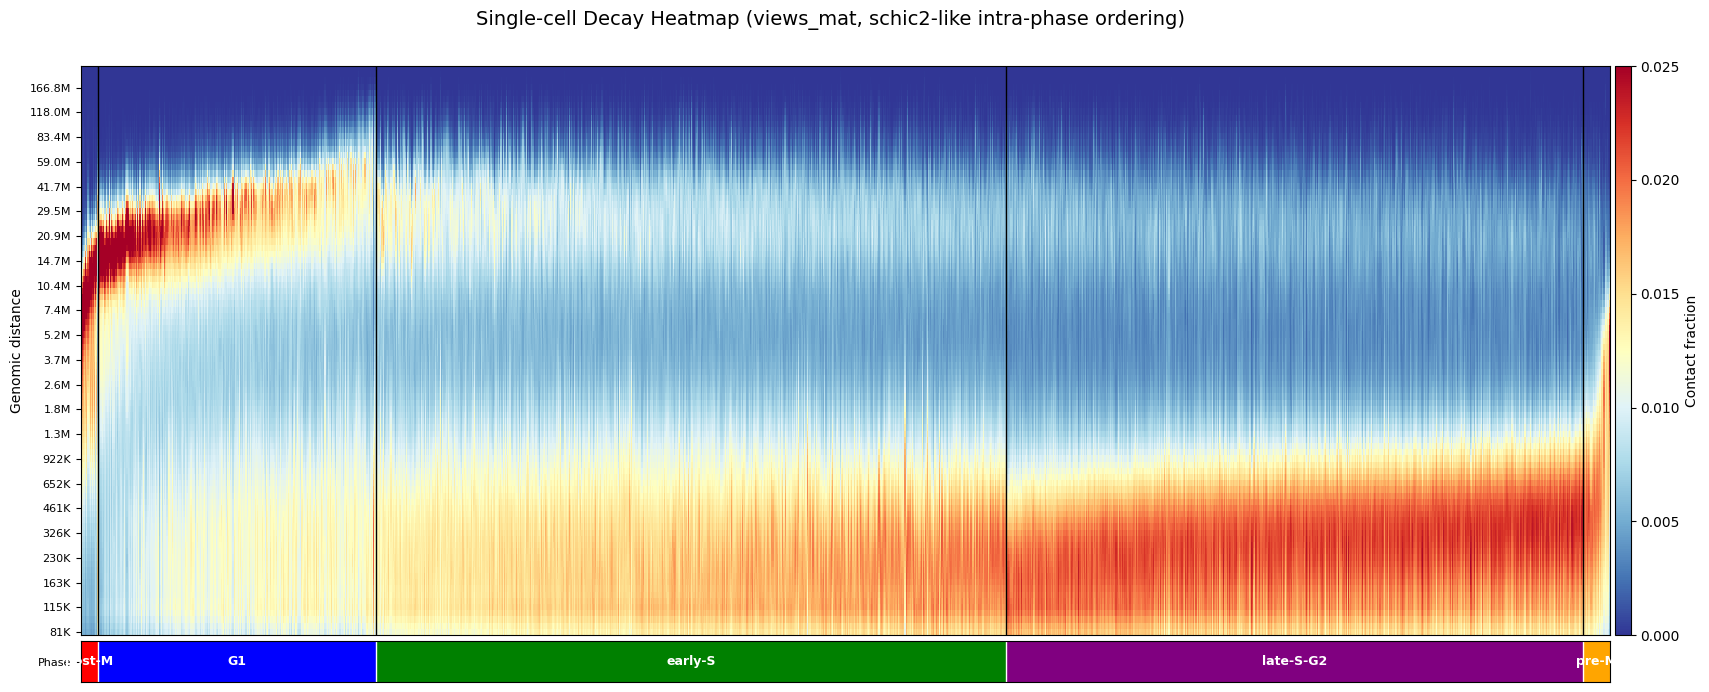

In [16]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ================= 1. 配置与参数 =================
resolution = 'hic_50000'
int_res = 50000
bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
n_bins = len(bin_edges) - 1
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['red', 'blue', 'green', 'purple', 'orange']

# 单细胞标签
cell_ct = hdata.obs['label'].to_dict()          # cell_name -> phase
cell_names = list(hdata.obs.index)
views_mat_dict = hdata.views_mat[resolution]    # dict: chrom -> list/array of sparse mats

rng = np.random.default_rng(1234)

# ================= 2. 计算衰减 =================
n_cells = len(hdata.obs)
cell_decay = np.zeros((n_cells, n_bins), dtype=np.float64)

print(f"Total single cells to process: {n_cells}")

for chrom, cell_mats in views_mat_dict.items():
    print(f"Processing {chrom} ...")

    for i, sparse_mat in enumerate(cell_mats):
        try:
            if sparse_mat is None or sparse_mat.nnz == 0:
                continue

            upper_coo = sp.triu(sparse_mat, k=1).tocoo()
            if upper_coo.nnz == 0:
                continue

            dists_bins = upper_coo.col - upper_coo.row
            vals = upper_coo.data.astype(np.float64)

            jitter = rng.uniform(-int_res / 2, int_res / 2, size=len(dists_bins))
            dists = np.maximum(dists_bins * int_res + jitter, 1.0)

            bin_idx = np.searchsorted(bin_edges, dists, side='right') - 1
            valid = (bin_idx >= 0) & (bin_idx < n_bins)

            if np.any(valid):
                cell_decay[i] += np.bincount(
                    bin_idx[valid],
                    weights=vals[valid],
                    minlength=n_bins
                )
        except Exception:
            pass

# ================= 3. 数据整理 =================
all_valid_cells = list(range(n_cells))

row_sums = cell_decay.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
norm_mat = cell_decay / row_sums

# 与你原代码保持一致：去掉太近的距离
min_dist_cutoff = 2 ** 16.2
valid_bins = bin_edges[:-1] >= min_dist_cutoff
trunc_mat = norm_mat[:, valid_bins]
valid_bin_mids = bin_mids[valid_bins]

# ================= 4. 定义 schic2-like 排序指标 =================
near_lo, near_hi = 2 ** 14.5, 2 ** 21
far_lo, far_hi = 2 ** 22.125, 2 ** 27.75
mit_lo, mit_hi = 2 ** 21, 2 ** 23.5
high_near_lo, high_near_hi = 2 ** 15, 2 ** 22

def frac_in_range(row, lo, hi):
    mask = (bin_mids >= lo) & (bin_mids < hi)
    if not np.any(mask):
        return 0.0
    return float(row[mask].sum())

def weighted_mean_in_range(row, lo, hi):
    mask = (bin_mids >= lo) & (bin_mids < hi)
    if not np.any(mask):
        return 0.0
    vals = row[mask]
    mids = bin_mids[mask]
    denom = vals.sum()
    if denom <= 0:
        return 0.0
    return float((vals * mids).sum() / denom)

cell_metrics = {}
for i in all_valid_cells:
    row = norm_mat[i]

    f_near = frac_in_range(row, near_lo, near_hi)
    f_far = frac_in_range(row, far_lo, far_hi)
    f_mit = frac_in_range(row, mit_lo, mit_hi)
    f_high_near = frac_in_range(row, high_near_lo, high_near_hi)
    far_mu = weighted_mean_in_range(row, far_lo, far_hi)

    # 没有真实 early_f 时，用近端富集做代理
    early_proxy = 0.5 * f_near + 0.5 * f_high_near

    cell_metrics[i] = {
        "f_near": f_near,
        "f_far": f_far,
        "f_mit": f_mit,
        "f_high_near": f_high_near,
        "far_mu": far_mu,
        "early_f": early_proxy,
    }

def zscore_metric(metric_name):
    vals = np.array([cell_metrics[i][metric_name] for i in all_valid_cells], dtype=np.float64)
    mu = vals.mean()
    sd = vals.std()
    if sd == 0:
        sd = 1.0
    return {i: (cell_metrics[i][metric_name] - mu) / sd for i in all_valid_cells}

z_near = zscore_metric("f_near")
z_far_mu = zscore_metric("far_mu")
z_early = zscore_metric("early_f")
z_mit = zscore_metric("f_mit")

# 额外保留一个 COM，方便你后面调试比较
n_cols = trunc_mat.shape[1]
col_indices = np.arange(n_cols)
com_scores = []
for i in all_valid_cells:
    row_data = trunc_mat[i]
    row_sum = row_data.sum()
    if row_sum > 0:
        probs = row_data / row_sum
        com_scores.append(float(np.sum(probs * col_indices)))
    else:
        com_scores.append(0.0)

# ================= 5. 按 phase 分组并组内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [i for i in all_valid_cells if cell_ct[cell_names[i]] == phase]

    if phase == 'post-M':
        # schic2: post-M / group1 按 mitotic band 降序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x],
            reverse=True
        )

    elif phase == 'G1':
        # schic2: G1 / group2 近似按 near + far_mu
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_far_mu[x]
        )

    elif phase == 'early-S':
        # schic2: early-S / group3 近似按 near + early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_early[x]
        )

    # elif phase == 'late-S-G2':
    #     # schic2: late-S-G2 / group4 近似按 near - early
    #     cells_in_phase_sorted = sorted(
    #         cells_in_phase,
    #         key=lambda x: z_near[x] - z_early[x]
    #     )[::-1]
    elif phase == 'late-S-G2':
        bottom_n = 50
        # 单细胞版：cells_in_phase 里的 i 已经是 norm_mat 的行号
        bottom_intensity = {
            i: norm_mat[i][valid_bins][:bottom_n].mean()
            for i in cells_in_phase
        }
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: bottom_intensity[x]
        )

    elif phase == 'pre-M':
        # schic2: pre-M / group5 按 mitotic band 升序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x]
        )

    else:
        cells_in_phase_sorted = cells_in_phase

    print(f"{phase}: {len(cells_in_phase_sorted)} cells")
    sorted_indices.extend(cells_in_phase_sorted)

n_sorted = len(sorted_indices)

# ================= 6. 构造绘图矩阵 =================
decay_mat = gaussian_filter1d(trunc_mat[sorted_indices], sigma=1.5, axis=1)

# ================= 7. 绘图 =================
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# --- 7.1 主热图 ---
ax_main = fig.add_subplot(gs[0])
zlim = (0, 0.025)
ax_main.grid(False)

im = ax_main.imshow(
    np.clip(decay_mat.T, zlim[0], zlim[1]),
    aspect='auto',
    cmap='RdYlBu_r',
    vmin=zlim[0],
    vmax=zlim[1],
    interpolation='nearest',
    origin='lower'
)

tick_every = 4
tick_pos = np.arange(0, valid_bins.sum(), tick_every)
tick_labels = [
    f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
    for v in valid_bin_mids[tick_pos]
]

ax_main.set_yticks(tick_pos)
ax_main.set_yticklabels(tick_labels, fontsize=8)
ax_main.set_xticks([])
ax_main.set_ylabel('Genomic distance')

divider = make_axes_locatable(ax_main)
ax_cb = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# phase 分隔线
cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    cum += cnt
    ax_main.axvline(cum - 0.5, color='black', linewidth=1)

# --- 7.2 Phase bar ---
ax_cond = fig.add_subplot(gs[1])
cond_colors = np.zeros((1, n_sorted, 3))
phase_color_map = dict(zip(phase_order, phase_colors))

for col, i in enumerate(sorted_indices):
    lb = cell_ct[cell_names[i]]
    cond_colors[0, col] = mcolors.to_rgb(phase_color_map[lb])

ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
ax_cond.set_xticks([])
ax_cond.set_yticks([0])
ax_cond.set_yticklabels(['Phase'], fontsize=8)
ax_cond.grid(False)

cum = 0
for phase in phase_order:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    if cnt > 0:
        center = cum + (cnt - 1) / 2
        ax_cond.text(
            center, 0, phase,
            ha='center', va='center',
            fontsize=9, color='white', fontweight='bold'
        )
    cum += cnt

cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for i in sorted_indices if cell_ct[cell_names[i]] == phase)
    cum += cnt
    ax_cond.axvline(cum - 0.5, color='white', linewidth=1)

divider_cond = make_axes_locatable(ax_cond)
ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
ax_cond_dummy.axis('off')

plt.suptitle(
    'Single-cell Decay Heatmap (views_mat, schic2-like intra-phase ordering)',
    fontsize=14,
    y=0.95
)
plt.show()

# ================= 8. 导出结果 =================
sc_sorted_indices = sorted_indices
sc_trunc_mat = trunc_mat
sc_com_scores = com_scores
sc_cell_ct = cell_ct
sc_cell_metrics = cell_metrics
sc_decay_mat = decay_mat
sc_sorted_cell_names = [cell_names[i] for i in sorted_indices]



Total cells to process: 30
post-M: 1 cells
G1: 4 cells
early-S: 12 cells
late-S-G2: 12 cells
pre-M: 1 cells


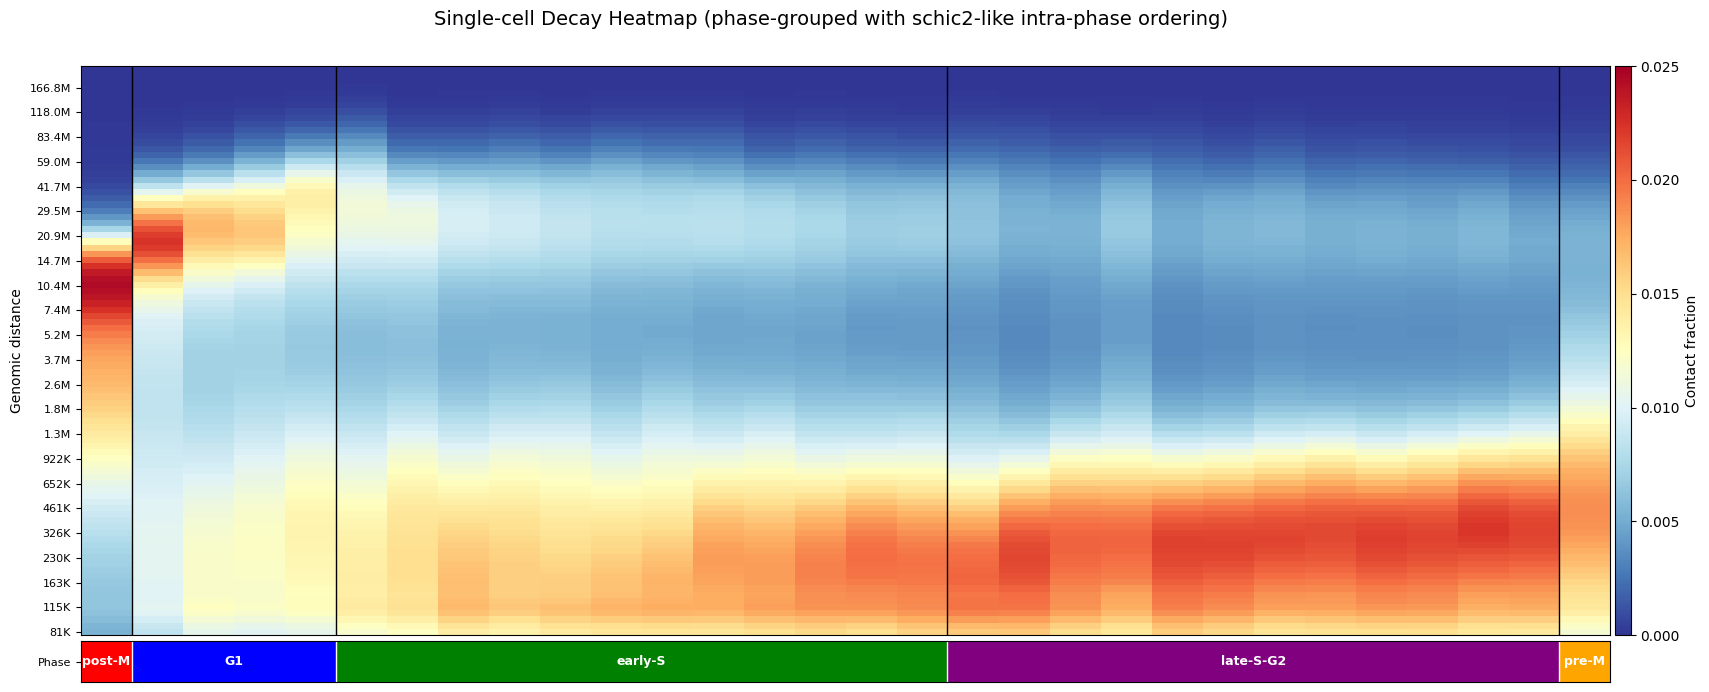

In [17]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ================= 1. 配置与参数 =================
resolution ='hic_50000'
int_res = 50000
bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
n_bins = len(bin_edges) - 1
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['red', 'blue', 'green', 'purple', 'orange']

metacell_ct = hdata.metacells.CellType.to_dict()
metacell_mat_dict = hdata.metacell_data['mat'][resolution]

rng = np.random.default_rng(1234)

# ================= 2. 计算 decay =================
metacell_decay = {}
print(f"Total cells to process: {len(metacell_mat_dict)}")

for cell_id, chrom_dict in metacell_mat_dict.items():
    decay_counts = np.zeros(n_bins, dtype=np.float64)

    for chrom, sparse_mat in chrom_dict.items():
        try:
            if sparse_mat is None or sparse_mat.nnz == 0:
                continue

            upper_coo = sp.triu(sparse_mat, k=1).tocoo()
            if upper_coo.nnz == 0:
                continue

            bin1 = upper_coo.row
            bin2 = upper_coo.col
            vals = upper_coo.data.astype(np.float64)

            dists_bins = bin2 - bin1

            # dithering: 避免所有 contact 都卡在 bin 边界
            jitter = rng.uniform(-int_res / 2, int_res / 2, size=len(dists_bins))
            dists = dists_bins * int_res + jitter
            dists = np.maximum(dists, 1.0)

            bin_idx = np.searchsorted(bin_edges, dists, side='right') - 1
            valid = (bin_idx >= 0) & (bin_idx < n_bins)

            if np.any(valid):
                counts = np.bincount(
                    bin_idx[valid],
                    weights=vals[valid],
                    minlength=n_bins
                )
                decay_counts += counts

        except Exception:
            pass

    metacell_decay[cell_id] = decay_counts

# ================= 3. 整理矩阵 =================
all_valid_cells = [idx for idx in metacell_decay if idx in metacell_ct]

raw_all = np.array([metacell_decay[idx] for idx in all_valid_cells], dtype=np.float64)
row_sums_all = raw_all.sum(axis=1, keepdims=True)
row_sums_all[row_sums_all == 0] = 1.0
norm_all = raw_all / row_sums_all

# 截断近距离，和你原代码保持一致
min_dist_cutoff = 2 ** 16.2
valid_bins = bin_edges[:-1] >= min_dist_cutoff
valid_bin_mids = bin_mids[valid_bins]

# ================= 4. 定义更接近 schic2 的排序指标 =================
# 这些区间参考 schic2 的参数设置
near_lo, near_hi = 2 ** 14.5, 2 ** 21
far_lo, far_hi = 2 ** 22.125, 2 ** 27.75
mit_lo, mit_hi = 2 ** 21, 2 ** 23.5

# 一个更高近端的窗口，可作为 early proxy 的一部分
high_near_lo, high_near_hi = 2 ** 15, 2 ** 22

all_bin_mids = bin_mids.copy()

def frac_in_range(row, lo, hi):
    mask = (all_bin_mids >= lo) & (all_bin_mids < hi)
    if not np.any(mask):
        return 0.0
    return float(row[mask].sum())

def weighted_mean_in_range(row, lo, hi):
    mask = (all_bin_mids >= lo) & (all_bin_mids < hi)
    if not np.any(mask):
        return 0.0
    vals = row[mask]
    mids = all_bin_mids[mask]
    denom = vals.sum()
    if denom <= 0:
        return 0.0
    return float((vals * mids).sum() / denom)

cell_metrics = {}
for i, idx in enumerate(all_valid_cells):
    row = norm_all[i]

    f_near = frac_in_range(row, near_lo, near_hi)
    f_far = frac_in_range(row, far_lo, far_hi)
    f_mit = frac_in_range(row, mit_lo, mit_hi)
    f_high_near = frac_in_range(row, high_near_lo, high_near_hi)
    far_mu = weighted_mean_in_range(row, far_lo, far_hi)

    # 没有真正 early_f 时，用近端富集做一个代理
    # 这里组合了 near 和 high_near，稳定性比单独 COM 稍好
    early_proxy = 0.8 * f_near + 0.1 * f_high_near

    cell_metrics[idx] = {
        "f_near": f_near,
        "f_far": f_far,
        "f_mit": f_mit,
        "f_high_near": f_high_near,
        "far_mu": far_mu,
        "early_f": early_proxy,
    }

# 标准化一下，避免不同量纲互相压制
def zscore_dict(metric_name):
    vals = np.array([cell_metrics[idx][metric_name] for idx in all_valid_cells], dtype=np.float64)
    mu = vals.mean()
    sd = vals.std()
    if sd == 0:
        sd = 1.0
    return {idx: (cell_metrics[idx][metric_name] - mu) / sd for idx in all_valid_cells}

z_near = zscore_dict("f_near")
z_far_mu = zscore_dict("far_mu")
z_early = zscore_dict("early_f")
z_mit = zscore_dict("f_mit")

# ================= 5. 周期内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]

    if phase == 'post-M':
        # schic2: group1 按 mitotic band 降序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x],
            reverse=True
        )

    elif phase == 'G1':
        # schic2: group2 近似按 near + far_mu
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_far_mu[x]
        )

    elif phase == 'early-S':
        # schic2: group3 近似按 near + early
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_near[x] + z_early[x]
        )

    elif phase == 'late-S-G2':
        # 按 heatmap 下部（short-range bins）平均强度从低到高排序
        bottom_n = 50  # 取截断后最下面 10 个 bin，可调
        # all_valid_cells 的顺序对应 norm_all 的行顺序
        idx_to_row = {idx: i for i, idx in enumerate(all_valid_cells)}
        bottom_intensity = {
            idx: norm_all[idx_to_row[idx]][valid_bins][:bottom_n].mean()
            for idx in cells_in_phase
        }
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: bottom_intensity[x]
        )

    elif phase == 'pre-M':
        # schic2: group5 按 mitotic band 升序
        cells_in_phase_sorted = sorted(
            cells_in_phase,
            key=lambda x: z_mit[x]
        )

    else:
        cells_in_phase_sorted = cells_in_phase

    print(f"{phase}: {len(cells_in_phase_sorted)} cells")
    sorted_indices.extend(cells_in_phase_sorted)

# ================= 6. 构造绘图矩阵 =================
n_cells = len(sorted_indices)

raw_mat = np.array([metacell_decay[idx] for idx in sorted_indices], dtype=np.float64)
row_sums = raw_mat.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
norm_mat = raw_mat / row_sums

trunc_mat = norm_mat[:, valid_bins]
decay_mat = gaussian_filter1d(trunc_mat, sigma=1.5, axis=1)

# ================= 7. 绘图 =================
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# --- 7.1 主热图 ---
ax_main = fig.add_subplot(gs[0])
zlim = (0, 0.025)

ax_main.grid(False)

im = ax_main.imshow(
    np.clip(decay_mat.T, zlim[0], zlim[1]),
    aspect='auto',
    cmap='RdYlBu_r',
    vmin=zlim[0],
    vmax=zlim[1],
    interpolation='nearest',
    origin='lower'
)

tick_every = 4
tick_pos = np.arange(0, len(valid_bin_mids), tick_every)
tick_labels = [
    f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
    for v in valid_bin_mids[tick_pos]
]

ax_main.set_yticks(tick_pos)
ax_main.set_yticklabels(tick_labels, fontsize=8)
ax_main.set_xticks([])
ax_main.set_ylabel('Genomic distance')

divider = make_axes_locatable(ax_main)
ax_cb = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# 相位分界线
cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    cum += cnt
    ax_main.axvline(cum - 0.5, color='black', linewidth=1)

# --- 7.2 条件色条 ---
ax_cond = fig.add_subplot(gs[1])

cond_colors = np.zeros((1, n_cells, 3))
phase_color_map = dict(zip(phase_order, phase_colors))

for col, idx in enumerate(sorted_indices):
    phase = metacell_ct[idx]
    cond_colors[0, col] = mcolors.to_rgb(phase_color_map[phase])

ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
ax_cond.set_xticks([])
ax_cond.set_yticks([0])
ax_cond.set_yticklabels(['Phase'], fontsize=8)
ax_cond.grid(False)

cum = 0
for phase in phase_order:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    if cnt > 0:
        center = cum + (cnt - 1) / 2
        ax_cond.text(
            center, 0, phase,
            ha='center', va='center',
            fontsize=9, color='white', fontweight='bold'
        )
        cum += cnt

cum = 0
for phase in phase_order[:-1]:
    cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
    cum += cnt
    ax_cond.axvline(cum - 0.5, color='white', linewidth=1)

divider_cond = make_axes_locatable(ax_cond)
ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
ax_cond_dummy.axis('off')

plt.suptitle(
    'Single-cell Decay Heatmap (phase-grouped with schic2-like intra-phase ordering)',
    fontsize=14,
    y=0.95
)
plt.savefig('./decayheatmap.pdf',dpi=300)
plt.show()

# ================= 8. 导出结果 =================
mc_sorted = sorted_indices
mc_decay_mat = decay_mat
mc_trunc = trunc_mat
sorted_metacells = sorted_indices
metacell_sort_metrics = cell_metrics
mc_decay = decay_mat
mc_ct = metacell_ct


metric                  mc8         mc3        diff
f_near               0.8229      0.7865     -0.0364
f_high_near          0.8201      0.8001     -0.0200
f_mit                0.0764      0.0967      0.0204
f_far                0.1411      0.1661      0.0250
far_mu         26592090.896724797086.4191-1795004.4776
early_f              0.7403      0.7092     -0.0311

late-S-G2 排序（你代码里的顺序）: [11, 8, 28, 22, 18, 12, 7, 24, 23, 3, 17, 4]
  mc8 排名: 2/12
  mc3 排名: 10/12


/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_75862/1255396386.py:45: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_75862/1255396386.py:45: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


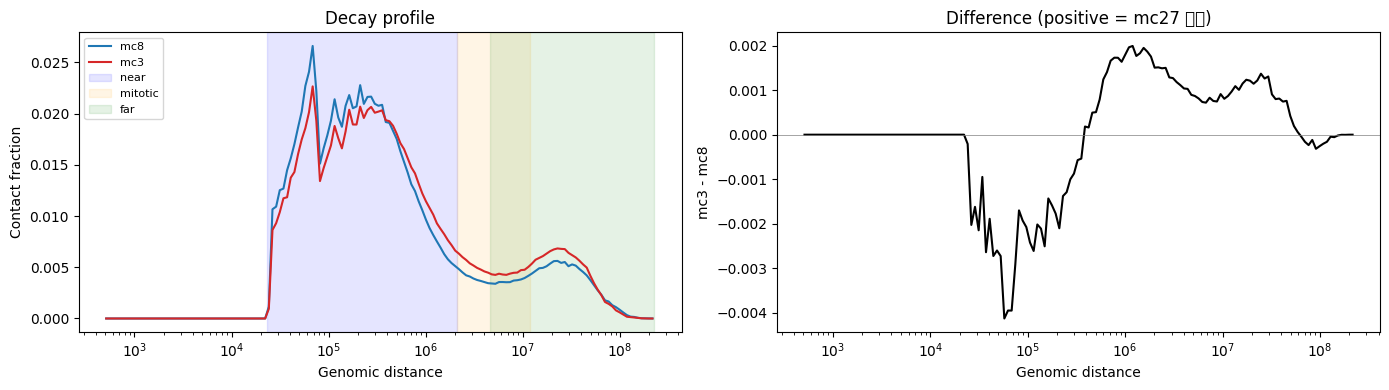

In [9]:
# ================= 9. Metacell #21 vs #27 诊断 =================
mc_a, mc_b = 8, 3

# 9.1 指标对比表
keys = ["f_near", "f_high_near", "f_mit", "f_far", "far_mu", "early_f"]
print(f"{'metric':<15}{f'mc{mc_a}':>12}{f'mc{mc_b}':>12}{'diff':>12}")
for k in keys:
    va, vb = cell_metrics[mc_a][k], cell_metrics[mc_b][k]
    print(f"{k:<15}{va:>12.4f}{vb:>12.4f}{vb - va:>12.4f}")

# 9.2 在所有 late-S-G2 metacell 中的相对位置
late_cells = [idx for idx in all_valid_cells if metacell_ct[idx] == 'late-S-G2']
late_sorted = sorted(late_cells, key=lambda x: z_near[x] - z_early[x])[::-1]
print("\nlate-S-G2 排序（你代码里的顺序）:", late_sorted)
print(f"  mc{mc_a} 排名: {late_sorted.index(mc_a)+1}/{len(late_sorted)}")
print(f"  mc{mc_b} 排名: {late_sorted.index(mc_b)+1}/{len(late_sorted)}")

# 9.3 decay 曲线叠加
ia = all_valid_cells.index(mc_a)
ib = all_valid_cells.index(mc_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 全量 decay 曲线
axes[0].plot(bin_mids, norm_all[ia], label=f'mc{mc_a}', color='C0')
axes[0].plot(bin_mids, norm_all[ib], label=f'mc{mc_b}', color='C3')
axes[0].set_xscale('log')
axes[0].axvspan(near_lo, near_hi, alpha=0.1, color='blue', label='near')
axes[0].axvspan(mit_lo, mit_hi, alpha=0.1, color='orange', label='mitotic')
axes[0].axvspan(far_lo, far_hi, alpha=0.1, color='green', label='far')
axes[0].set_xlabel('Genomic distance')
axes[0].set_ylabel('Contact fraction')
axes[0].legend(fontsize=8)
axes[0].set_title('Decay profile')

# 差值曲线
diff = norm_all[ib] - norm_all[ia]
axes[1].plot(bin_mids, diff, color='black')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Genomic distance')
axes[1].set_ylabel(f'mc{mc_b} - mc{mc_a}')
axes[1].set_title('Difference (positive = mc27 更高)')

plt.tight_layout()
plt.show()

In [10]:
# ================= 5. 周期内排序 =================
sorted_indices = []

for phase in phase_order:
    cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]

    if phase == 'post-M':
        key_fn = lambda x: z_mit[x]
        key_name = "z_mit (desc)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn, reverse=True)

    elif phase == 'G1':
        key_fn = lambda x: z_near[x] + z_far_mu[x]
        key_name = "z_near + z_far_mu"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    elif phase == 'early-S':
        key_fn = lambda x: z_near[x] + z_early[x]
        key_name = "z_near + z_early"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    elif phase == 'late-S-G2':
        key_fn = lambda x: z_near[x] - z_early[x]
        key_name = "z_near - z_early (reversed)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)[::-1]

    elif phase == 'pre-M':
        key_fn = lambda x: z_mit[x]
        key_name = "z_mit (asc)"
        cells_in_phase_sorted = sorted(cells_in_phase, key=key_fn)

    else:
        key_fn = lambda x: 0
        key_name = "none"
        cells_in_phase_sorted = cells_in_phase

    # 打印排序值
    print(f"\n=== {phase} ({len(cells_in_phase_sorted)} cells, key = {key_name}) ===")
    print(f"{'rank':>4}  {'cell_id':<20}  {'sort_val':>10}  "
          f"{'z_near':>8}  {'z_far_mu':>8}  {'z_early':>8}  {'z_mit':>8}")
    for r, cid in enumerate(cells_in_phase_sorted):
        print(f"{r:>4}  {str(cid):<20}  {key_fn(cid):>10.4f}  "
              f"{z_near[cid]:>8.3f}  {z_far_mu[cid]:>8.3f}  "
              f"{z_early[cid]:>8.3f}  {z_mit[cid]:>8.3f}")

    sorted_indices.extend(cells_in_phase_sorted)


=== post-M (1 cells, key = z_mit (desc)) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  2                         4.6822    -2.879    -4.111    -2.821     4.682

=== G1 (4 cells, key = z_near + z_far_mu) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  10                       -3.6682    -2.282    -1.386    -2.298     1.373
   1  6                        -2.0665    -1.528    -0.539    -1.548     0.715
   2  16                       -1.4606    -1.553     0.092    -1.569     0.636
   3  21                       -0.1549    -1.270     1.116    -1.283     0.436

=== early-S (12 cells, key = z_near + z_early) ===
rank  cell_id                 sort_val    z_near  z_far_mu   z_early     z_mit
   0  25                       -1.7630    -0.874     1.554    -0.889     0.209
   1  29                       -1.2069    -0.601     0.194    -0.606     0.253
   2  1                        -0.4702    -0.231     0.406    -0.

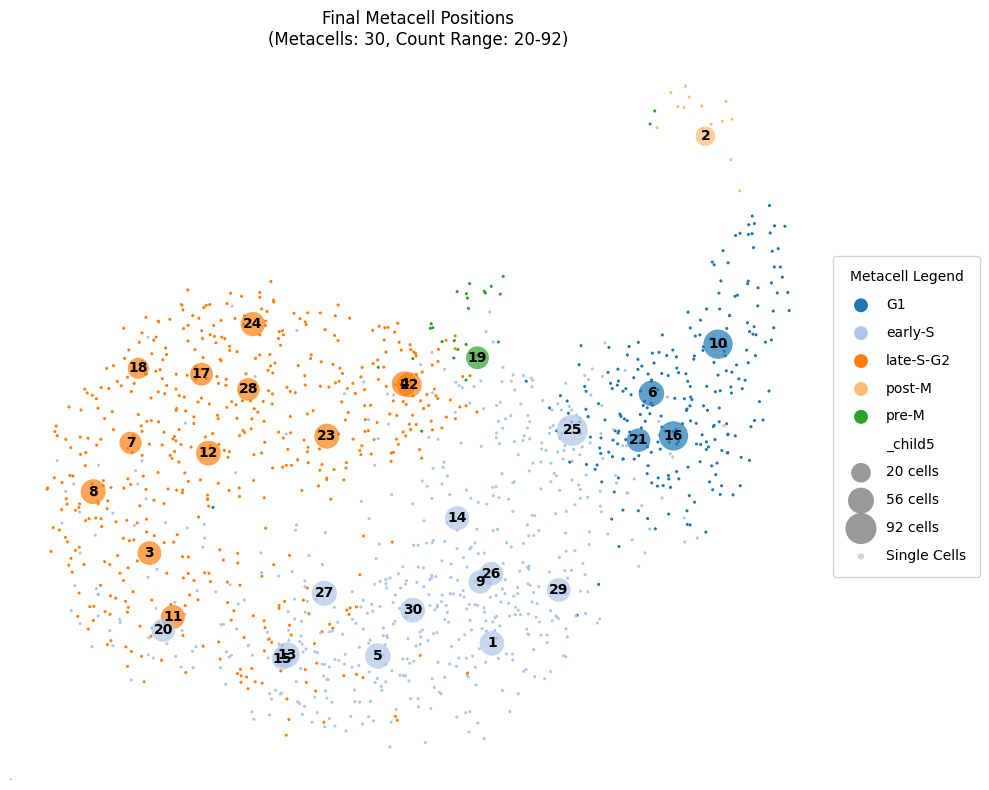

In [11]:
sk.pl.plot_metacells2(hdata, resolution=1000000, title="Final Metacell Positions",
             min_size=200, max_size=500, 
             show_idx=True, label_col='label', 
             cell_alpha=1, metacell_alpha=0.7)


In [12]:
# import numpy as np
# import scipy.sparse as sp
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from scipy.ndimage import gaussian_filter1d
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# # ================= 1. 配置与参数 =================
# resolution = 50000

# bin_edges = np.concatenate([[0], 2 ** np.arange(10, 27.875, 0.125)])
# n_bins = len(bin_edges) - 1
# bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

# phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
# phase_colors = ['Red', 'Blue', 'green', 'purple', 'orange']
# metacell_ct = hdata.metacells.CellType.to_dict()
# metacell_mat_dict = hdata.metacell_data['mat'][str(resolution)]

# # ================= 2. 计算衰减 (加入 Dithering) =================
# metacell_decay = {}
# print(f"Total cells to process: {len(metacell_mat_dict)}")

# for cell_id, chrom_dict in metacell_mat_dict.items():
#     decay_counts = np.zeros(n_bins, dtype=np.float32)
    
#     for chrom, sparse_mat in chrom_dict.items():
#         try:
#             if sparse_mat.nnz == 0: 
#                 continue
            
#             upper_coo = sp.triu(sparse_mat, k=1).tocoo()
#             if upper_coo.nnz == 0: 
#                 continue
            
#             bin1 = upper_coo.row
#             bin2 = upper_coo.col
#             vals = upper_coo.data.astype(np.float32)
            
#             dists_bins = bin2 - bin1
#             jitter = np.random.uniform(-resolution/2, resolution/2, size=len(dists_bins))
#             dists = dists_bins * resolution + jitter
#             dists = np.maximum(dists, 1.0) 
            
#             bin_idx = np.searchsorted(bin_edges, dists) - 1
#             valid = (bin_idx >= 0) & (bin_idx < n_bins)
            
#             if valid.any():
#                 counts = np.bincount(bin_idx[valid], weights=vals[valid], minlength=n_bins)
#                 decay_counts += counts
                
#         except Exception as e:
#             pass
            
#     metacell_decay[cell_id] = decay_counts

# # ================= 3. 数据整理、截断与排序 =================
# all_valid_cells = [idx for idx in metacell_decay.keys() if idx in metacell_ct]

# temp_mat = np.array([metacell_decay[idx] for idx in all_valid_cells])
# temp_row_sums = temp_mat.sum(axis=1, keepdims=True)
# temp_row_sums[temp_row_sums == 0] = 1
# temp_norm_mat = temp_mat / temp_row_sums

# min_dist_cutoff = 2 ** 16.2
# valid_bins = bin_edges[:-1] >= min_dist_cutoff
# temp_trunc_mat = temp_norm_mat[:, valid_bins]

# n_cols = temp_trunc_mat.shape[1]
# col_indices = np.arange(n_cols)

# cell_com_scores = {}
# for i, idx in enumerate(all_valid_cells):
#     row_data = temp_trunc_mat[i]
#     row_sum = row_data.sum()
#     if row_sum > 0:
#         probs = row_data / row_sum
#         com = np.sum(probs * col_indices)
#     else:
#         com = 0
#     cell_com_scores[idx] = com

# sorted_indices = []
# for phase in phase_order:
#     cells_in_phase = [idx for idx in all_valid_cells if metacell_ct[idx] == phase]
#     cells_in_phase_sorted = sorted(cells_in_phase, key=lambda x: cell_com_scores[x])
#     if phase == 'G1' or phase == 'early-S' or phase == 'late-S-G2':

#             cells_in_phase_sorted = cells_in_phase_sorted[::-1]
#     print(cells_in_phase_sorted)
#     print(phase)
#     sorted_indices.extend(cells_in_phase_sorted)

# n_cells = len(sorted_indices)

# raw_mat = np.array([metacell_decay[idx] for idx in sorted_indices])
# row_sums = raw_mat.sum(axis=1, keepdims=True)
# row_sums[row_sums == 0] = 1
# norm_mat = raw_mat / row_sums

# n_valid_bins = valid_bins.sum()
# trunc_mat = norm_mat[:, valid_bins]

# decay_mat = gaussian_filter1d(trunc_mat, sigma=1.5, axis=1)

# # ================= 4. 绘图 =================
# fig = plt.figure(figsize=(20, 8))
# gs = fig.add_gridspec(2, 1, height_ratios=[14, 1], hspace=0.02)

# # --- 4.1 主热图 ---
# ax_main = fig.add_subplot(gs[0])
# zlim = (0, 0.025)

# ax_main.grid(visible=False, axis='y')
# ax_main.grid(visible=False, axis='x')

# im = ax_main.imshow(
#     np.clip(decay_mat.T, zlim[0], zlim[1]),
#     aspect='auto',
#     cmap='RdYlBu_r', 
#     vmin=zlim[0],
#     vmax=zlim[1],
#     interpolation='nearest',
#     origin='lower' 
# )

# valid_bin_mids = bin_mids[valid_bins]
# tick_every = 4
# tick_pos = np.arange(0, n_valid_bins, tick_every)
# tick_labels = [f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
#                for v in valid_bin_mids[tick_pos]]

# ax_main.set_yticks(tick_pos)
# ax_main.set_yticklabels(tick_labels, fontsize=8)
# ax_main.set_xticks([])  
# ax_main.set_ylabel('Genomic distance')

# divider = make_axes_locatable(ax_main)
# ax_cb = divider.append_axes("right", size="1%", pad=0.05)
# plt.colorbar(im, cax=ax_cb, label='Contact fraction')

# # --- 4.2 条件色条 (Phase Bar) ---
# ax_cond = fig.add_subplot(gs[1])
# cond_colors = np.zeros((1, n_cells, 3))

# phase_color_map = dict(zip(phase_order, phase_colors))
# for col, idx in enumerate(sorted_indices):
#     lb = metacell_ct[idx]
#     rgb = mcolors.to_rgb(phase_color_map[lb])
#     cond_colors[0, col] = rgb

# ax_cond.imshow(cond_colors, aspect='auto', interpolation='nearest')
# ax_cond.set_xticks([])
# ax_cond.set_yticks([0])
# ax_cond.set_yticklabels(['Phase'], fontsize=8)
# ax_cond.grid(False) 

# cum = 0
# for phase in phase_order:
#     cnt = sum(1 for idx in sorted_indices if metacell_ct[idx] == phase)
#     if cnt > 0:
#         ax_cond.text(cum + cnt/2 - cnt*0.5, 0, phase, ha='center', va='center',
#              fontsize=9, color='white', fontweight='bold')
#     cum += cnt

# # ax_cond 右侧加占位，与 ax_main 对齐
# divider_cond = make_axes_locatable(ax_cond)
# ax_cond_dummy = divider_cond.append_axes("right", size="1%", pad=0.05)
# ax_cond_dummy.axis('off')

# # --- 4.3 排版 ---
# plt.suptitle('Single-cell Decay Heatmap (Grouped by phase, smoothed internally)', fontsize=14, y=0.95)
# plt.show()
# mc_sorted = sorted_indices        # 改这里
# mc_decay_mat = decay_mat          # 改这里
# mc_trunc = trunc_mat              # 改这里
# sorted_metacells = sorted_indices
# metacell_com = cell_com_scores
# mc_sorted = sorted_metacells   # 用sorted_metacells而不是sorted_indices
# mc_decay = decay_mat
# mc_ct = metacell_ct

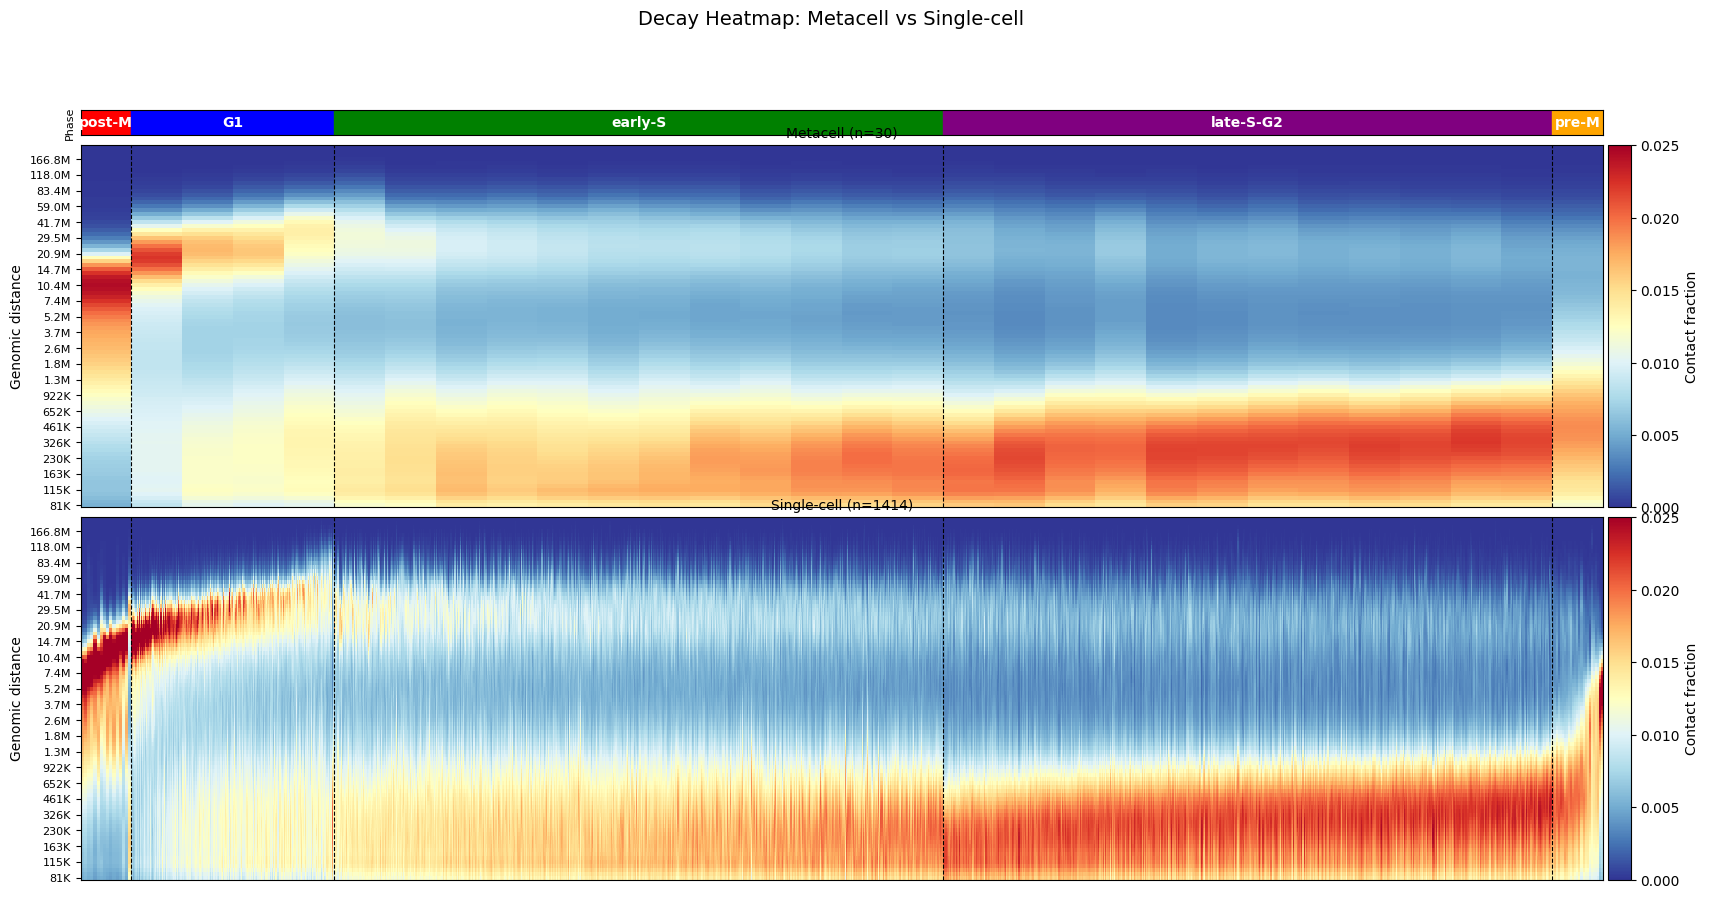

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter1d

phase_order = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = ['Red', 'Blue', 'green', 'purple', 'orange']
phase_color_map = dict(zip(phase_order, phase_colors))

# ================= 数据准备 =================
# metacell（文档6变量）
mc_sorted = sorted_indices          # metacell排好序的id列表
mc_decay = decay_mat                # (n_mc, n_valid_bins)，已gaussian
mc_ct = metacell_ct                 # id -> phase

# 单细胞（文档5变量，需要重新命名避免冲突）
# 假设文档5的变量存为：sc_sorted_indices, sc_decay_mat, sc_trunc_mat
# 如果变量名有冲突请告诉我，我来调整

# phase在metacell中的count
mc_phase_cnt = {p: sum(1 for idx in mc_sorted if mc_ct[idx] == p) for p in phase_order}
# phase在单细胞中的count  
cell_obs_index = list(hdata.obs.index)
sc_phase_cnt = {p: sum(1 for i in sc_sorted_indices if cell_ct[cell_obs_index[i]] == p) for p in phase_order}

# 计算每个phase的归一化宽度（按metacell比例，两图共用）
total_mc = sum(mc_phase_cnt.values())
phase_widths = {p: mc_phase_cnt[p] / total_mc for p in phase_order}  # 归一化物理宽度

# 构建x坐标映射：把每个cell/metacell映射到统一的[0,1]物理空间
def make_extent_blocks(sorted_list, ct_dict, phase_order, phase_widths):
    """返回每列对应的物理x坐标"""
    x_coords = np.zeros(len(sorted_list) + 1)
    cum_phys = 0
    pos = 0
    for phase in phase_order:
        cells = [idx for idx in sorted_list if ct_dict[idx] == phase]
        n = len(cells)
        if n == 0:
            continue
        w = phase_widths[phase]
        for k in range(n):
            x_coords[pos + k] = cum_phys + k * w / n
        pos += n
        cum_phys += w
    x_coords[-1] = 1.0
    return x_coords

# metacell x坐标
mc_x = make_extent_blocks(mc_sorted, mc_ct, phase_order, phase_widths)

# 单细胞需要用整数index映射
def make_extent_blocks_sc(sorted_list, obs_index, ct_dict, phase_order, phase_widths):
    x_coords = np.zeros(len(sorted_list) + 1)
    cum_phys = 0
    pos = 0
    for phase in phase_order:
        cells = [i for i in sorted_list if ct_dict[obs_index[i]] == phase]
        n = len(cells)
        if n == 0:
            continue
        w = phase_widths[phase]
        for k in range(n):
            x_coords[pos + k] = cum_phys + k * w / n
        pos += n
        cum_phys += w
    x_coords[-1] = 1.0
    return x_coords

sc_x = make_extent_blocks_sc(sc_sorted_indices, cell_obs_index, cell_ct, phase_order, phase_widths)

# ================= 绘图 =================
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[0.5, 7, 7], hspace=0.04)

valid_bin_mids = bin_mids[valid_bins]
tick_every = 4
tick_pos = np.arange(0, valid_bins.sum(), tick_every)
tick_labels = [f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K' for v in valid_bin_mids[tick_pos]]

# --- Phase bar（共用，最上面）---
ax_phase = fig.add_subplot(gs[0])
cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if w > 0:
        ax_phase.axvspan(cum_phys, cum_phys + w, color=phase_color_map[phase], alpha=1)
        ax_phase.text(cum_phys + w/2, 0.5, phase, ha='center', va='center',
                      fontsize=10, color='white', fontweight='bold',
                      transform=ax_phase.get_xaxis_transform())
        cum_phys += w
ax_phase.set_xlim(0, 1)
ax_phase.set_xticks([])
ax_phase.set_yticks([])
ax_phase.set_ylabel('Phase', fontsize=8)

divider_phase = make_axes_locatable(ax_phase)
ax_phase_dummy = divider_phase.append_axes("right", size="1.5%", pad=0.05)
ax_phase_dummy.axis('off')

# --- Metacell 热图 ---
ax_mc = fig.add_subplot(gs[1])
zlim = (0, 0.025)

# 用pcolormesh支持非等宽列
X_mc, Y_mc = np.meshgrid(mc_x, np.arange(mc_decay.shape[1] + 1) - 0.5)
im_mc = ax_mc.pcolormesh(X_mc, Y_mc,
                          np.clip(mc_decay.T, zlim[0], zlim[1]),
                          cmap='RdYlBu_r', vmin=zlim[0], vmax=zlim[1],
                          shading='flat')

ax_mc.set_yticks(tick_pos)
ax_mc.set_yticklabels(tick_labels, fontsize=8)
ax_mc.set_xticks([])
ax_mc.set_ylabel('Genomic distance')
ax_mc.set_xlim(0, 1)
ax_mc.set_title(f'Metacell (n={len(mc_sorted)})', fontsize=10)

divider_mc = make_axes_locatable(ax_mc)
ax_cb_mc = divider_mc.append_axes("right", size="1.5%", pad=0.05)
plt.colorbar(im_mc, cax=ax_cb_mc, label='Contact fraction')

# phase边界线
cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if cum_phys > 0:
        ax_mc.axvline(cum_phys, color='black', lw=0.8, linestyle='--')
    cum_phys += w

# --- 单细胞热图 ---
ax_sc = fig.add_subplot(gs[2])
sc_decay_plot = gaussian_filter1d(sc_trunc_mat[sc_sorted_indices], sigma=1.5, axis=1)

X_sc, Y_sc = np.meshgrid(sc_x, np.arange(sc_decay_plot.shape[1] + 1) - 0.5)
im_sc = ax_sc.pcolormesh(X_sc, Y_sc,
                          np.clip(sc_decay_plot.T, zlim[0], zlim[1]),
                          cmap='RdYlBu_r', vmin=zlim[0], vmax=zlim[1],
                          shading='flat')

ax_sc.set_yticks(tick_pos)
ax_sc.set_yticklabels(tick_labels, fontsize=8)
ax_sc.set_xticks([])
ax_sc.set_ylabel('Genomic distance')
ax_sc.set_xlim(0, 1)
ax_sc.set_title(f'Single-cell (n={len(sc_sorted_indices)})', fontsize=10)

divider_sc = make_axes_locatable(ax_sc)
ax_cb_sc = divider_sc.append_axes("right", size="1.5%", pad=0.05)
plt.colorbar(im_sc, cax=ax_cb_sc, label='Contact fraction')

cum_phys = 0
for phase in phase_order:
    w = phase_widths[phase]
    if cum_phys > 0:
        ax_sc.axvline(cum_phys, color='black', lw=0.8, linestyle='--')
    cum_phys += w

plt.suptitle('Decay Heatmap: Metacell vs Single-cell', fontsize=14, y=0.98)
plt.savefig('decay_heatmap_combined.pdf', bbox_inches='tight')
plt.show()

In [14]:
# # 构建 metacell -> pseudotime rank 的映射
# import seaborn as sns
# mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}

# def plot_metacells_pseudotime(hdata, sorted_metacells, resolution=None, title="Metacell Pseudotime Order",
#                                min_size=50, max_size=500, label_col='label',
#                                cell_alpha=0.3, metacell_alpha=0.8, save_path=None, dpi=300):
#     if resolution is None:
#         raise ValueError("请提供 resolution 参数")

#     import pandas as pd
#     labels = hdata.obs['metacell']
#     umap_coords = hdata.views_umap[resolution]
#     present_indices = np.unique(labels)

#     cell_labels = hdata.obs[label_col].values
#     if 'eval_df_cache' in hdata.uns:
#         unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
#     else:
#         unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
#     palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
#     color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

#     metacell_coords, metacell_counts, metacell_dominant_labels = [], [], []
#     for k in present_indices:
#         indices = np.where(labels == k)[0]
#         metacell_coords.append(np.mean(umap_coords[indices], axis=0))
#         metacell_counts.append(len(indices))
#         dom_label = pd.Series(cell_labels[indices]).value_counts().index[0]
#         metacell_dominant_labels.append(dom_label)

#     metacell_coords = np.array(metacell_coords)
#     metacell_counts = np.array(metacell_counts)

#     if metacell_counts.max() > metacell_counts.min():
#         norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
#         plot_sizes = min_size + norm_sizes * (max_size - min_size)
#     else:
#         plot_sizes = np.full(len(metacell_counts), (min_size + max_size) / 2)

#     mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
#     mc_colors = [color_map.get(lbl, 'blue') for lbl in metacell_dominant_labels]
#     cell_colors_list = [color_map.get(lbl, 'lightgrey') for lbl in cell_labels]

#     plt.figure(figsize=(10, 8))
#     plt.scatter(umap_coords[:, 0], umap_coords[:, 1],
#                 c=cell_colors_list, s=5, alpha=cell_alpha, rasterized=True, edgecolors='none', linewidth=0)
#     plt.scatter(metacell_coords[:, 0], metacell_coords[:, 1],
#                 c=mc_colors, s=plot_sizes, edgecolors='none', linewidths=0, alpha=metacell_alpha, zorder=10)

#     # 标注pseudotime rank
#     for i, k in enumerate(present_indices):
#         rank = mc_pseudotime_rank.get(k, '?')
#         plt.text(metacell_coords[i, 0], metacell_coords[i, 1], str(rank),
#                  fontsize=9, ha='center', va='center', color='white', fontweight='bold', zorder=20)

#     handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
#                for lbl in unified_hue_order]
#     handles.append(plt.scatter([], [], c='white', s=0, label=''))
#     min_c, max_c = metacell_counts.min(), metacell_counts.max()
#     mid_c = int((min_c + max_c) / 2)
#     for s, l in zip([min_size, (min_size+max_size)/2, max_size],
#                     [f'{min_c} cells', f'{mid_c} cells', f'{max_c} cells']):
#         handles.append(plt.scatter([], [], c='gray', alpha=0.8, s=s, edgecolors='none', label=l))
#     handles.append(plt.scatter([], [], c='lightgrey', s=20, edgecolors='none', label='Single Cells'))

#     plt.legend(handles=handles, title="Metacell Legend", loc='center left',
#                bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)
#     plt.title(f"{title}\n(Metacells: {len(metacell_coords)}, pseudotime rank labeled)")
#     plt.axis('off')
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
#     plt.show()

# plot_metacells_pseudotime(hdata, sorted_metacells, resolution=1000000)

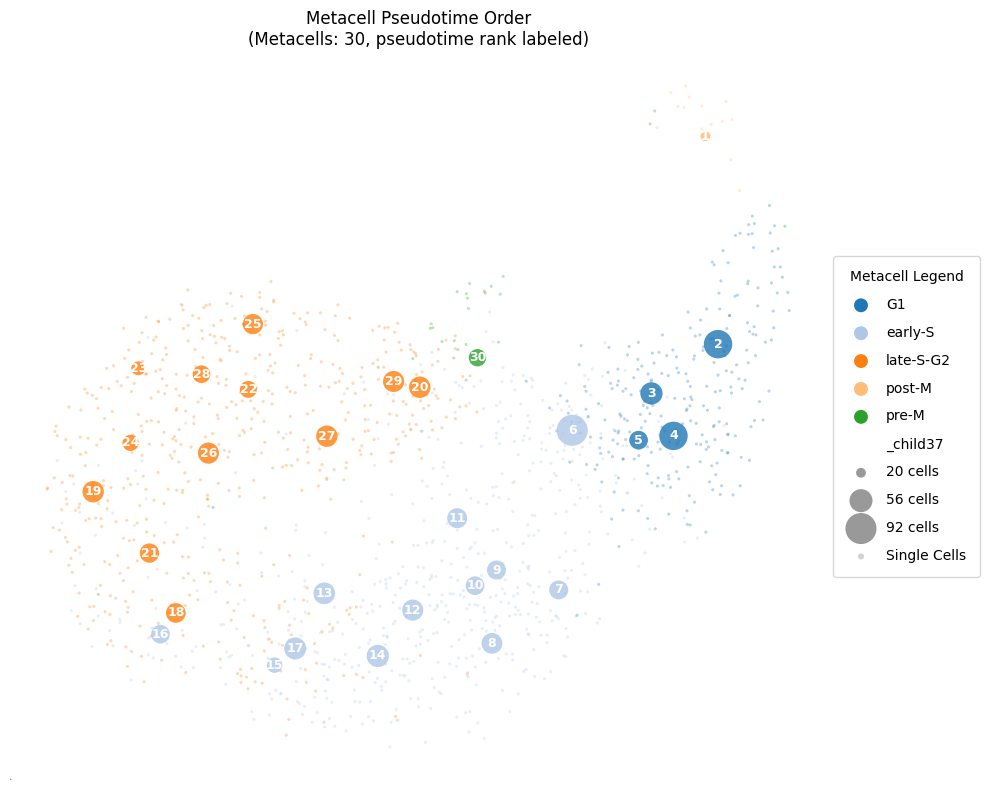

In [15]:
# 构建 metacell -> pseudotime rank 的映射
import seaborn as sns
mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
def plot_metacells_pseudotime(hdata, sorted_metacells, resolution=None, title="Metacell Pseudotime Order",
                               min_size=50, max_size=500, label_col='label',
                               cell_alpha=0.3, metacell_alpha=0.8, save_path=None, dpi=300,
                               recompute_umap=False, umap_neighbors=10, umap_min_dist=1,
                               repulse=True, repulse_radius=0.5, repulse_iters=50):
    if resolution is None:
        raise ValueError("请提供 resolution 参数")

    import pandas as pd
    import umap
    labels = hdata.obs['metacell']

    if recompute_umap:
        print('recompute umap')
        pca_coords = hdata.views_pca[resolution]
        reducer = umap.UMAP(n_neighbors=umap_neighbors, min_dist=umap_min_dist, random_state=42)
        umap_coords = reducer.fit_transform(pca_coords)
    else:
        umap_coords = hdata.views_umap[resolution]

    present_indices = np.unique(labels)
    cell_labels = hdata.obs[label_col].values
    if 'eval_df_cache' in hdata.uns:
        unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
    else:
        unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
    palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
    color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

    metacell_coords, metacell_counts, metacell_dominant_labels = [], [], []
    for k in present_indices:
        indices = np.where(labels == k)[0]
        metacell_coords.append(np.mean(umap_coords[indices], axis=0))
        metacell_counts.append(len(indices))
        dom_label = pd.Series(cell_labels[indices]).value_counts().index[0]
        metacell_dominant_labels.append(dom_label)

    metacell_coords = np.array(metacell_coords)
    metacell_counts = np.array(metacell_counts)

    # repulsion：将过近的 metacell 点推开
    if repulse:
        for _ in range(repulse_iters):
            for i in range(len(metacell_coords)):
                for j in range(i+1, len(metacell_coords)):
                    diff = metacell_coords[i] - metacell_coords[j]
                    dist = np.linalg.norm(diff)
                    if dist < repulse_radius and dist > 1e-6:
                        push = (repulse_radius - dist) / 2 * diff / dist
                        metacell_coords[i] += push
                        metacell_coords[j] -= push

    if metacell_counts.max() > metacell_counts.min():
        norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
        plot_sizes = min_size + norm_sizes * (max_size - min_size)
    else:
        plot_sizes = np.full(len(metacell_counts), (min_size + max_size) / 2)

    mc_pseudotime_rank = {mc: i+1 for i, mc in enumerate(sorted_metacells)}
    mc_colors = [color_map.get(lbl, 'blue') for lbl in metacell_dominant_labels]
    cell_colors_list = [color_map.get(lbl, 'lightgrey') for lbl in cell_labels]

    plt.figure(figsize=(10, 8))
    plt.scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=cell_colors_list, s=5, alpha=cell_alpha, rasterized=True, edgecolors='none', linewidth=0)
    plt.scatter(metacell_coords[:, 0], metacell_coords[:, 1],
                c=mc_colors, s=plot_sizes, edgecolors='none', linewidths=0, alpha=metacell_alpha, zorder=10)

    for i, k in enumerate(present_indices):
        rank = mc_pseudotime_rank.get(k, '?')
        plt.text(metacell_coords[i, 0], metacell_coords[i, 1], str(rank),
                 fontsize=9, ha='center', va='center', color='white', fontweight='bold', zorder=20)

    handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
               for lbl in unified_hue_order]
    handles.append(plt.scatter([], [], c='white', s=0, label=''))
    min_c, max_c = metacell_counts.min(), metacell_counts.max()
    mid_c = int((min_c + max_c) / 2)
    for s, l in zip([min_size, (min_size+max_size)/2, max_size],
                    [f'{min_c} cells', f'{mid_c} cells', f'{max_c} cells']):
        handles.append(plt.scatter([], [], c='gray', alpha=0.8, s=s, edgecolors='none', label=l))
    handles.append(plt.scatter([], [], c='lightgrey', s=20, edgecolors='none', label='Single Cells'))

    plt.legend(handles=handles, title="Metacell Legend", loc='center left',
               bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)
    plt.title(f"{title}\n(Metacells: {len(metacell_coords)}, pseudotime rank labeled)")
    plt.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
plot_metacells_pseudotime(hdata, sorted_metacells, resolution=1000000, save_path='./time_umap.pdf')

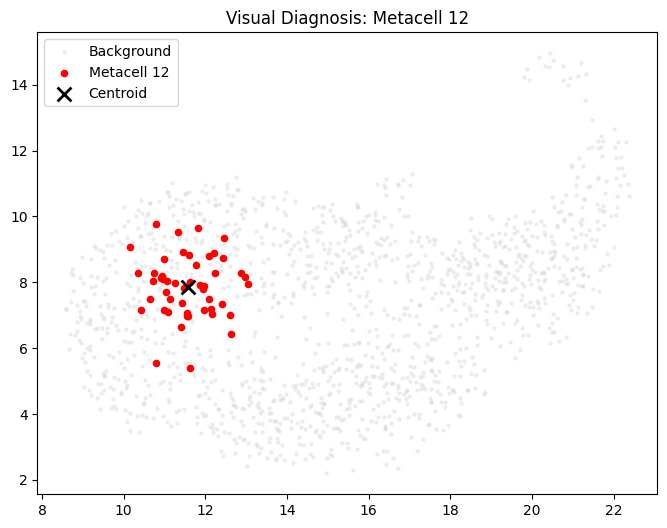

In [16]:
sk.pl.plot_specific_metacell(hdata, metacell_id=12, resolution=1000000)


In [17]:
# import umap
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ================= 用decay profile重新跑UMAP =================
# decay_for_umap = temp_trunc_mat[[mc - 1 for mc in sorted_metacells]]

# reducer = umap.UMAP(n_neighbors=5, min_dist=1, metric='cosine', random_state=42)
# mc_umap_coords = reducer.fit_transform(decay_for_umap)

# # ================= 绘图 =================
# cell_labels = hdata.obs['label'].values
# if 'eval_df_cache' in hdata.uns:
#     unified_hue_order = sorted(hdata.uns['eval_df_cache']['CellType'].dropna().unique())
# else:
#     unified_hue_order = sorted(pd.Series(cell_labels).dropna().unique())
# palette = sns.color_palette('tab20', n_colors=len(unified_hue_order))
# color_map = {lbl: palette[i] for i, lbl in enumerate(unified_hue_order)}

# mc_colors = [color_map.get(metacell_ct[mc], 'gray') for mc in sorted_metacells]
# metacell_counts = np.array([sum(hdata.obs['metacell'] == mc) for mc in sorted_metacells])

# if metacell_counts.max() > metacell_counts.min():
#     norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
#     plot_sizes = 50 + norm_sizes * 450
# else:
#     plot_sizes = np.full(len(metacell_counts), 250)

# fig, ax = plt.subplots(figsize=(10, 8))

# # 画连线
# for i in range(len(sorted_metacells) - 1):
#     x0, y0 = mc_umap_coords[i]
#     x1, y1 = mc_umap_coords[i+1]
#     ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
#                 arrowprops=dict(arrowstyle='->', color='gray', lw=1.0, alpha=0.6))

# # 散点
# ax.scatter(mc_umap_coords[:, 0], mc_umap_coords[:, 1],
#            c=mc_colors, s=plot_sizes, edgecolors='white', linewidths=0.5,
#            alpha=0.9, zorder=10)

# # 标注pseudotime rank
# for i, mc in enumerate(sorted_metacells):
#     ax.text(mc_umap_coords[i, 0], mc_umap_coords[i, 1], str(i+1),
#             fontsize=8, ha='center', va='center', color='white', fontweight='bold', zorder=20)

# handles = [plt.scatter([], [], c=[color_map[lbl]], s=100, edgecolors='none', label=lbl)
#            for lbl in unified_hue_order]
# ax.legend(handles=handles, title='Phase', loc='center left',
#           bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)

# ax.set_title('Metacell UMAP (decay profile, pseudotime labeled)')
# ax.axis('off')
# plt.tight_layout()
# plt.savefig('metacell_decay_umap.pdf', bbox_inches='tight')
# plt.show()

In [18]:
hdata

HData object with 1414 cells and 30 metacells
    resolutions: [10000, np.int64(50000), np.int64(100000), np.int64(500000), np.int64(1000000), np.int64(2000000)]
    obs: ['depth', 'label', 'metacell']
    views_pca: [1000000, 50000, 500000, 10000]
    views_umap: [1000000, 50000, 500000, 10000]
    views_embedding: [1000000, 50000, 500000]
    views_mat: [1000000, 50000, 500000, 10000]
    views_is: []
    uns keys: ['accuracy', 'avg_size_cache', 'cs_res_df', 'eval_df_cache', 'global_score', 'hwis', 'mean_compactness', 'mean_separation', 'metrics', 'purity_df', 'recommended_k', 'thre_cache', 'wcos']
    metacells: ['CellType', 'CellType_purity', 'cell_num', 'w_min', 'w_max', 'P_adj', 'EP_v2', 'total_depth', 'cell_count', 'mean_depth', 'dominant_label']
    metacell_data keys: ['cool', 'mat', 'mcool', 'pairs']
    model: MultiViewSEACells (trained: True)

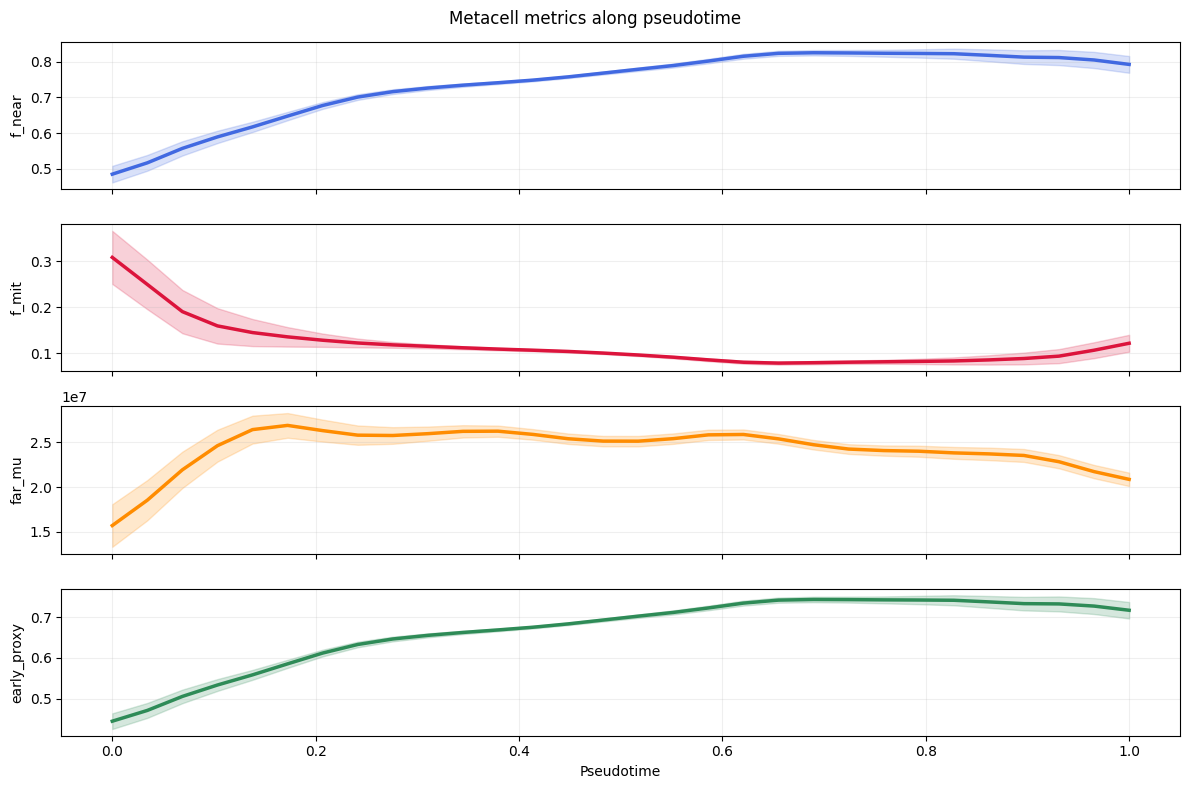

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 以当前排序作为拟时序
pseudotime = np.linspace(0, 1, len(sorted_indices))

pt_metrics = {
    "f_near": np.array([cell_metrics[idx]["f_near"] for idx in sorted_indices], dtype=float),
    "f_mit": np.array([cell_metrics[idx]["f_mit"] for idx in sorted_indices], dtype=float),
    "far_mu": np.array([cell_metrics[idx]["far_mu"] for idx in sorted_indices], dtype=float),
    "early_proxy": np.array([cell_metrics[idx]["early_f"] for idx in sorted_indices], dtype=float),
}

def smooth_with_band(vals, sigma_mean=1.5, sigma_sd=3):
    mean_s = gaussian_filter1d(vals, sigma=sigma_mean)
    resid2 = (vals - mean_s) ** 2
    sd_s = np.sqrt(gaussian_filter1d(resid2, sigma=sigma_sd))
    return mean_s, sd_s

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

metric_colors = {
    "f_near": "royalblue",
    "f_mit": "crimson",
    "far_mu": "darkorange",
    "early_proxy": "seagreen",
}

for ax, (name, vals) in zip(axes, pt_metrics.items()):
    mean_s, sd_s = smooth_with_band(vals, sigma_mean=1.2, sigma_sd=2.5)
    color = metric_colors[name]

    ax.fill_between(
        pseudotime,
        mean_s - sd_s,
        mean_s + sd_s,
        color=color,
        alpha=0.2
    )
    ax.plot(pseudotime, mean_s, color=color, linewidth=2.5)
    ax.set_ylabel(name)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Pseudotime")
plt.suptitle("Metacell metrics along pseudotime", y=0.98)
plt.tight_layout()
plt.show()


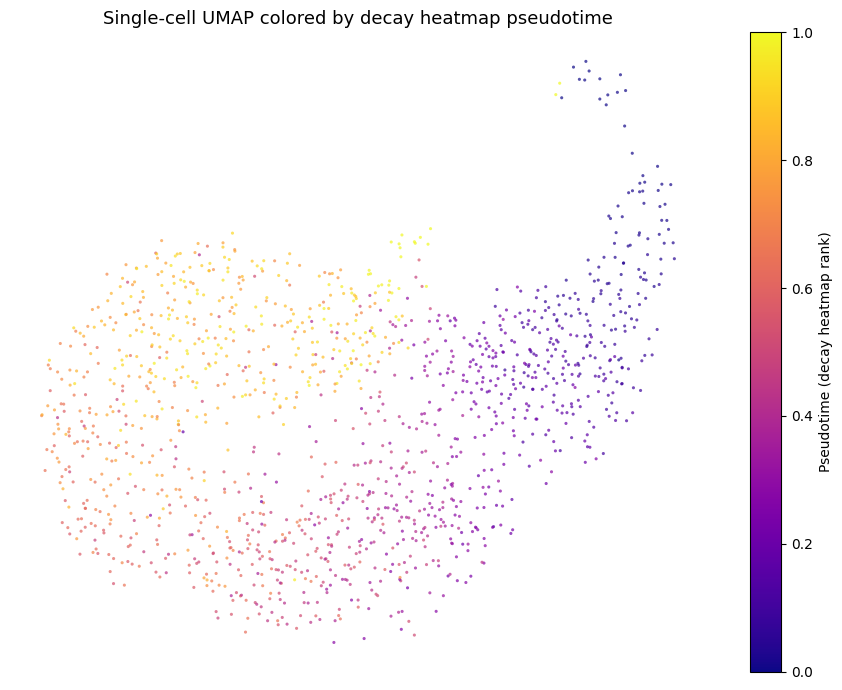

In [20]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ================= 1. 构建单细胞拟时序值 =================
# sc_sorted_indices 是按 decay heatmap 排好序的细胞索引列表
# 给每个细胞赋拟时序值 [0, 1]
n_sc = len(sc_sorted_indices)
pseudotime_values = np.linspace(0, 1, n_sc)

# cell_index -> pseudotime
cell_pseudotime = np.full(len(cell_names), np.nan)
for rank, cell_idx in enumerate(sc_sorted_indices):
    cell_pseudotime[cell_idx] = pseudotime_values[rank]

# ================= 2. 获取 UMAP 坐标 =================
umap_coords = hdata.views_umap[1000000]   # shape: (n_cells, 2)

# ================= 3. 绘图 =================
fig, ax = plt.subplots(figsize=(9, 7))

cmap = plt.get_cmap('plasma')
norm = Normalize(vmin=0, vmax=1)

# 先画没有拟时序值的细胞（灰色背景）
no_pt_mask = np.isnan(cell_pseudotime)
if no_pt_mask.any():
    ax.scatter(
        umap_coords[no_pt_mask, 0], umap_coords[no_pt_mask, 1],
        s=3, color='lightgrey', alpha=0.3, edgecolors='none', rasterized=True
    )

# 再画有拟时序值的细胞，按拟时序着色
pt_mask = ~no_pt_mask
sc = ax.scatter(
    umap_coords[pt_mask, 0], umap_coords[pt_mask, 1],
    c=cell_pseudotime[pt_mask],
    cmap=cmap, norm=norm,
    s=5, alpha=0.7, edgecolors='none', rasterized=True
)

plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Pseudotime (decay heatmap rank)')
ax.set_title('Single-cell UMAP colored by decay heatmap pseudotime', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('umap_pseudotime.pdf', bbox_inches='tight')
plt.show()


Fitting UMAP on single-cell decay profiles ...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done.


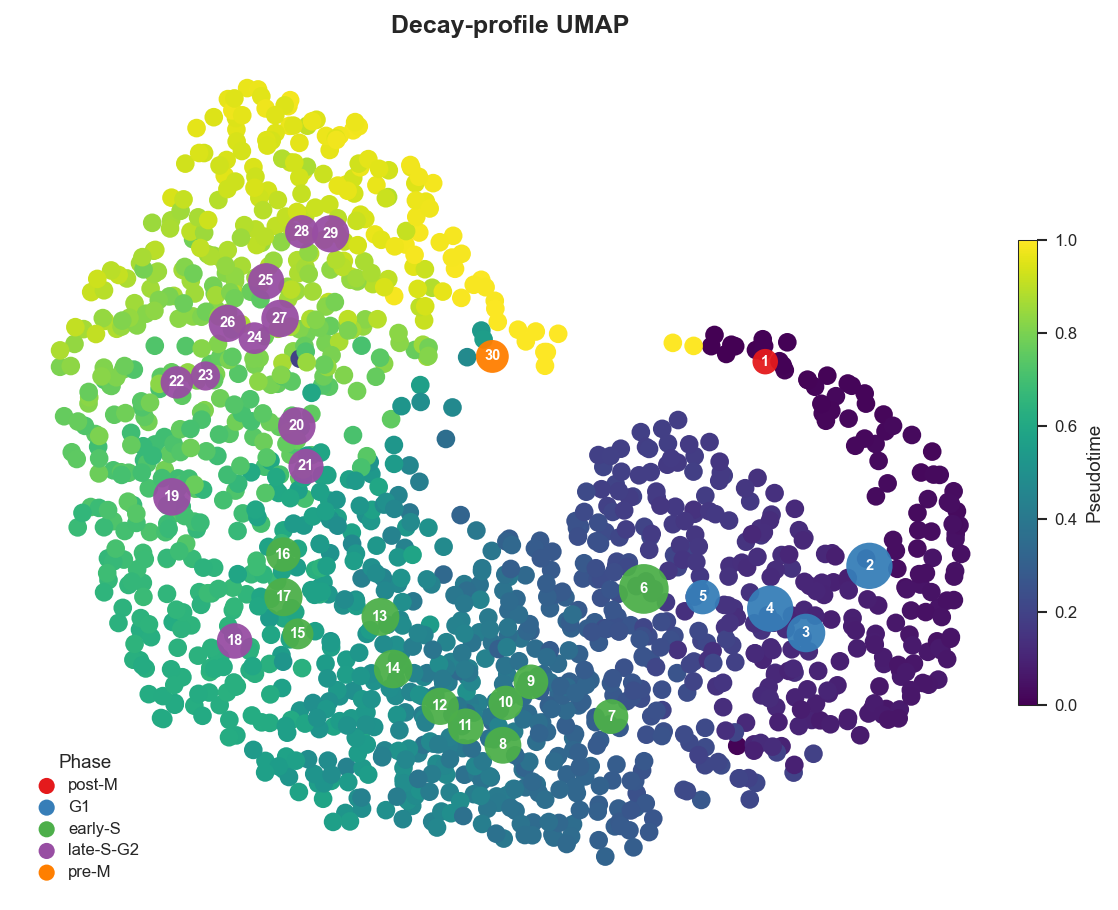

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import umap as umap_lib
import seaborn as sns

# ================= 配色方案（SCI 风格）=================
# 单细胞拟时序：viridis（蓝→绿→黄，常见于 Nature/Science scRNA-seq 图）
CMAP_PT = 'viridis'

# metacell 分期颜色：使用 ColorBrewer Set1 派生的高饱和可辨色
PHASE_COLORS = {
    'post-M':    '#E41A1C',   # 红
    'G1':        '#377EB8',   # 蓝
    'early-S':   '#4DAF4A',   # 绿
    'late-S-G2': '#984EA3',   # 紫
    'pre-M':     '#FF7F00',   # 橙
}
phase_order_local = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']

# ================= 1. 用单细胞 decay 向量拟合 UMAP =================
print("Fitting UMAP on single-cell decay profiles ...")
reducer = umap_lib.UMAP(n_neighbors=20, min_dist=1, n_jobs=1)
sc_umap_coords = reducer.fit_transform(sc_trunc_mat)   # (n_cells, 2)
print("UMAP done.")

# ================= 2. metacell UMAP 坐标 = 其包含单细胞坐标的均值 =================
mc_assign = hdata.obs['metacell'].values

mc_umap_coords = np.zeros((len(sorted_metacells), 2))
for i, mc_id in enumerate(sorted_metacells):
    member_mask = mc_assign == mc_id
    if member_mask.any():
        mc_umap_coords[i] = sc_umap_coords[member_mask].mean(axis=0)

# ================= 2.5 排斥：将过近的 metacell 点推开 =================
repulse_radius = 0.8
repulse_iters  = 100

mc_coords_r = mc_umap_coords.copy()
for _ in range(repulse_iters):
    moved = False
    for i in range(len(mc_coords_r)):
        for j in range(i + 1, len(mc_coords_r)):
            diff = mc_coords_r[i] - mc_coords_r[j]
            dist = np.linalg.norm(diff)
            if dist < repulse_radius and dist > 1e-8:
                push = (repulse_radius - dist) / 2.0 * diff / dist
                mc_coords_r[i] += push
                mc_coords_r[j] -= push
                moved = True
    if not moved:
        break
mc_umap_coords = mc_coords_r

# ================= 3. 单细胞拟时序着色 =================
n_sc_total = sc_trunc_mat.shape[0]
cell_pseudotime_decay = np.full(n_sc_total, np.nan)
for rank_i, cell_idx in enumerate(sc_sorted_indices):
    cell_pseudotime_decay[cell_idx] = rank_i / (len(sc_sorted_indices) - 1)

# ================= 4. metacell 尺寸（按包含细胞数） =================
mc_sizes_map = {mc_id: int((mc_assign == mc_id).sum()) for mc_id in sorted_metacells}
mc_sizes_arr = np.array([mc_sizes_map[mc_id] for mc_id in sorted_metacells], dtype=float)
if mc_sizes_arr.max() > mc_sizes_arr.min():
    norm_sz = (mc_sizes_arr - mc_sizes_arr.min()) / (mc_sizes_arr.max() - mc_sizes_arr.min())
    mc_plot_sizes = 150 + norm_sz * 420
else:
    mc_plot_sizes = np.full(len(sorted_metacells), 200.0)

mc_face_colors = [PHASE_COLORS.get(mc_ct.get(mc_id, ''), '#888888') for mc_id in sorted_metacells]

# ================= 5. 绘图 =================
norm_pt = Normalize(vmin=0, vmax=1)

sns.set_theme(style='white', context='paper',
              rc={'axes.linewidth': 0, 'font.family': 'sans-serif'})

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 5.1 单细胞散点（按拟时序着色）
no_pt = np.isnan(cell_pseudotime_decay)
if no_pt.any():
    ax.scatter(sc_umap_coords[no_pt, 0], sc_umap_coords[no_pt, 1],
               s=80, color='#CCCCCC', alpha=0.3, edgecolors='none', rasterized=True)

has_pt = ~no_pt
sc_scatter = ax.scatter(
    sc_umap_coords[has_pt, 0], sc_umap_coords[has_pt, 1],
    c=cell_pseudotime_decay[has_pt],
    cmap=CMAP_PT, norm=norm_pt,
    s=80, alpha=1, edgecolors='none', rasterized=True,
)

# 5.2 metacell 散点（分期颜色，无边框）
ax.scatter(mc_umap_coords[:, 0], mc_umap_coords[:, 1],
           c=mc_face_colors, s=mc_plot_sizes,
           edgecolors='none', linewidths=0, alpha=0.95, zorder=10)

# 5.3 metacell rank 标注
for i, mc_id in enumerate(sorted_metacells):
    ax.text(mc_umap_coords[i, 0], mc_umap_coords[i, 1], str(i + 1),
            fontsize=7, ha='center', va='center',
            color='white', fontweight='bold', zorder=20)

# 5.4 colorbar（拟时序，紧凑样式）
cbar = plt.colorbar(ScalarMappable(norm=norm_pt, cmap=CMAP_PT), ax=ax,
                    shrink=0.55, pad=0.01, aspect=25)
cbar.set_label('Pseudotime', fontsize=9)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_linewidth(0.5)

# 5.5 phase 图例（无边框，紧凑）
legend_handles = [
    plt.scatter([], [], c=[PHASE_COLORS[p]], s=60,
                edgecolors='none', linewidths=0, label=p)
    for p in phase_order_local
]
ax.legend(handles=legend_handles, title='Phase',
          title_fontsize=9, fontsize=8,
          loc='lower left', frameon=False,
          handletextpad=0.3, labelspacing=0.4)

ax.set_title('Decay-profile UMAP', fontsize=12, pad=8, fontweight='bold')
ax.axis('off')
plt.tight_layout(pad=0.5)
plt.savefig('decay_umap_pseudotime_mc_rank.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [20]:
import pandas as pd

# ================= 诊断：查看每个 metacell 的排序指标 =================
rank_target = 27   # 修改这里检查不同的 rank

diag_rows = []
for rank_i, mc_id in enumerate(sorted_metacells):
    phase = mc_ct.get(mc_id, '?')
    m = metacell_sort_metrics[mc_id]
    diag_rows.append({
        'rank': rank_i + 1,
        'mc_id': mc_id,
        'phase': phase,
        'f_near': m['f_near'],
        'f_mit': m['f_mit'],
        'far_mu': m['far_mu'],
        'early_f': m['early_f'],
        'f_far': m['f_far'],
    })

diag_df = pd.DataFrame(diag_rows)

# 打印完整表格
print("=== 所有 metacell 排序指标 ===")
print(diag_df.to_string(index=False, float_format='%.4f'))

# 打印目标 rank 附近的情况
print(f"\n=== rank {rank_target} 附近 (±3) ===")
mask = (diag_df['rank'] >= rank_target - 3) & (diag_df['rank'] <= rank_target + 3)
print(diag_df[mask].to_string(index=False, float_format='%.4f'))

# 打印每个 phase 的排序 key 值，方便对比
print("\n=== 各 phase 内排序 key ===")
for phase in ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']:
    sub = diag_df[diag_df['phase'] == phase].copy()
    if phase == 'post-M':
        sub['sort_key'] = -sub['f_mit']   # 降序
    elif phase == 'G1':
        sub['sort_key'] = sub['f_near'] + sub['far_mu']
    elif phase == 'early-S':
        sub['sort_key'] = sub['f_near'] + sub['early_f']
    elif phase == 'late-S-G2':
        sub['sort_key'] = -(sub['f_near'] - sub['early_f'])  # 降序后的等价升序key
    elif phase == 'pre-M':
        sub['sort_key'] = sub['f_mit']
    print(f"\n{phase}:")
    print(sub[['rank','mc_id','sort_key','f_near','f_mit','far_mu','early_f']].to_string(index=False, float_format='%.4f'))


=== 所有 metacell 排序指标 ===
 rank  mc_id     phase  f_near  f_mit        far_mu  early_f  f_far
    1      2    post-M  0.4502 0.3989 11804057.8533   0.4177 0.3943
    2     10        G1  0.5100 0.2006 20060324.4487   0.4638 0.4109
    3      6        G1  0.5856 0.1612 22625849.9750   0.5299 0.3500
    4     16        G1  0.5831 0.1564 24537135.0708   0.5281 0.3514
    5     21        G1  0.6114 0.1445 27637659.2501   0.5534 0.3258
    6     25   early-S  0.6511 0.1308 28964679.1681   0.5881 0.2917
    7     29   early-S  0.6784 0.1335 24845343.5924   0.6131 0.2624
    8      1   early-S  0.7155 0.1163 25489056.5188   0.6454 0.2325
    9     26   early-S  0.7159 0.1187 26040665.9314   0.6461 0.2292
   10      9   early-S  0.7267 0.1182 25272829.0470   0.6556 0.2183
   11     14   early-S  0.7379 0.1087 26889964.0983   0.6650 0.2123
   12     30   early-S  0.7396 0.1114 26341585.6792   0.6670 0.2072
   13     27   early-S  0.7470 0.1052 26452060.4800   0.6737 0.2030
   14      5   early-S 

In [25]:
import os
import re
import sys
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import cooler

# cooler<0.10 与 NumPy 2.0 兼容补丁
setattr(np, 'unicode_', np.str_)
APA_RES = 10000
# ================= 配置 =================
# 合并模式：'all'（整体一个 cool）| 'by_group'（按分组列每类一个 cool）| 'both'（两者都生成）
COOL_MERGE_MODE = 'all'

# 分组列名：可用任意标签列，不要求是细胞周期 phase
GROUP_COL = 'label'

NOTEBOOK_DIR = Path.cwd()
MUSTACHE_SCRIPT = NOTEBOOK_DIR / 'mustache.py'
OUT_DIR = NOTEBOOK_DIR / 'mustache_cycle_loops'
COOL_DIR = OUT_DIR / 'cool'
TSV_DIR = OUT_DIR / 'tsv'
CSV_DIR = OUT_DIR / 'csv'

for d in [OUT_DIR, COOL_DIR, TSV_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MUSTACHE_PT = 0.2
MUSTACHE_ST = 0.88
MUSTACHE_DIST_BP = 1_000_000
MUSTACHE_PROCESSES = 4

if not MUSTACHE_SCRIPT.exists():
    raise FileNotFoundError(f'Cannot find mustache script: {MUSTACHE_SCRIPT}')

if COOL_MERGE_MODE not in {'all', 'by_group', 'both'}:
    raise ValueError("COOL_MERGE_MODE must be one of: 'all', 'by_group', 'both'")

print('Mustache script:', MUSTACHE_SCRIPT)
print('Output dir     :', OUT_DIR)
print('COOL merge mode:', COOL_MERGE_MODE)

# ================= 1) 准备单细胞分组 =================
sc_views = hdata.views_mat[APA_RES]   # chrom -> list[sparse_mat], list index 对应 cell index
cell_names = list(hdata.obs.index)
n_cells_total = len(cell_names)

if GROUP_COL in hdata.obs.columns:
    group_values = hdata.obs[GROUP_COL].astype(str).tolist()
else:
    raise KeyError(f"GROUP_COL '{GROUP_COL}' not found in hdata.obs")


def sanitize_tag(s):
    s = str(s).strip()
    s = re.sub(r'\s+', '_', s)
    s = re.sub(r'[^0-9A-Za-z._-]+', '_', s)
    s = s.strip('._-')
    return s if s else 'unknown'


# group_name -> list[cell_idx]
pool_groups = {}
if COOL_MERGE_MODE in {'all', 'both'}:
    pool_groups['all'] = list(range(n_cells_total))

if COOL_MERGE_MODE in {'by_group', 'both'}:
    by_group = defaultdict(list)
    for i, g in enumerate(group_values):
        by_group[g].append(i)

    for g, idxs in sorted(by_group.items(), key=lambda x: x[0]):
        if len(idxs) == 0:
            continue
        pool_groups[f'grp_{sanitize_tag(g)}'] = idxs

if len(pool_groups) == 0:
    raise ValueError('No valid groups found for pooling.')

print(f'Pooling groups (from {GROUP_COL}):')
for g, idxs in pool_groups.items():
    print(f'  {g}: {len(idxs)} cells')


# ================= 2) 从指定细胞索引池化 sparse 矩阵 =================
def pool_chrom_mats_by_indices(sc_views_dict, indices):
    pooled = {}
    idx_set = set(indices)

    for chrom, cell_mats in sc_views_dict.items():
        acc = None
        n_local = len(cell_mats)

        for i in idx_set:
            if i >= n_local:
                continue
            mat = cell_mats[i]
            if mat is None or mat.nnz == 0:
                continue

            mat_f = mat.astype(np.float32)
            if acc is None:
                acc = mat_f.copy()
            else:
                acc = acc + mat_f

        if acc is not None and acc.nnz > 0:
            pooled[chrom] = acc

    return pooled


# ================= 3) 导出 pooled 矩阵到 cooler =================
def build_bins_from_dict(chrom_dict, resolution, chrom_order=None):
    if chrom_order is None:
        chrom_order = sorted(chrom_dict.keys())

    bins_rows = []
    chrom_offsets = {}
    offset = 0

    for chrom in chrom_order:
        if chrom not in chrom_dict:
            continue
        n_bins = chrom_dict[chrom].shape[0]
        chrom_offsets[chrom] = offset
        starts = np.arange(0, n_bins * resolution, resolution, dtype=np.int64)
        ends = starts + resolution
        bins_rows.extend({'chrom': chrom, 'start': int(s), 'end': int(e)} for s, e in zip(starts, ends))
        offset += n_bins

    return pd.DataFrame(bins_rows), chrom_offsets


def pooled_to_pixels_df(chrom_dict, chrom_offsets):
    pixel_chunks = []
    for chrom, mat in chrom_dict.items():
        if mat is None or mat.nnz == 0:
            continue

        sym = (mat + mat.T).astype(np.float64) * 0.5
        tri = sp.triu(sym, k=0).tocoo()

        counts = np.rint(tri.data).astype(np.int64)
        keep = counts > 0
        if not np.any(keep):
            continue

        off = chrom_offsets[chrom]
        chunk = pd.DataFrame({
            'bin1_id': tri.row[keep].astype(np.int64) + off,
            'bin2_id': tri.col[keep].astype(np.int64) + off,
            'count': counts[keep],
        })
        pixel_chunks.append(chunk)

    if not pixel_chunks:
        return pd.DataFrame(columns=['bin1_id', 'bin2_id', 'count'])

    pixels_df = pd.concat(pixel_chunks, axis=0, ignore_index=True)
    pixels_df = pixels_df.sort_values(['bin1_id', 'bin2_id'], kind='mergesort').reset_index(drop=True)
    return pixels_df


def write_single_cool(chrom_dict, resolution, out_cool_path):
    chrom_order = [c for c in getattr(hdata, 'chrom_list', list(chrom_dict.keys())) if c in chrom_dict]
    bins_df, chrom_offsets = build_bins_from_dict(chrom_dict, resolution, chrom_order=chrom_order)
    pixels_df = pooled_to_pixels_df(chrom_dict, chrom_offsets)

    if out_cool_path.exists():
        out_cool_path.unlink()

    cooler.create_cooler(
        cool_uri=str(out_cool_path),
        bins=bins_df,
        pixels=pixels_df,
        ordered=True,
        dtypes={'count': np.int64},
    )
    return out_cool_path, len(bins_df), len(pixels_df)


pooled_chrom_mats = {}      # group_name -> chrom_dict
pooled_cool_paths = {}      # group_name -> Path
pooled_cool_stats = {}      # group_name -> dict

for group_name, idxs in pool_groups.items():
    pooled = pool_chrom_mats_by_indices(sc_views, idxs)
    pooled_chrom_mats[group_name] = pooled

    total_nnz = int(sum(m.nnz for m in pooled.values()))
    print(f'[{group_name}] pooled chroms={len(pooled)}, nnz={total_nnz}')

    cool_name = 'all_cells' if group_name == 'all' else group_name
    out_path = COOL_DIR / f'{cool_name}.res{APA_RES}.cool'

    out_path, nbins, npix = write_single_cool(pooled, APA_RES, out_path)
    pooled_cool_paths[group_name] = out_path
    pooled_cool_stats[group_name] = {
        'n_cells': len(idxs),
        'n_chroms': len(pooled),
        'nbins': int(nbins),
        'npixels': int(npix),
        'path': str(out_path),
    }
    print(f'  -> wrote {out_path.name}, bins={nbins}, pixels={npix}')

# 兼容旧变量名：如果生成了 all，则保留 all_cool_path
all_cool_path = pooled_cool_paths.get('all', None)
if all_cool_path is not None:
    print(f'Compatibility var all_cool_path = {all_cool_path}')

print('Done. Generated cool groups:', list(pooled_cool_paths.keys()))

Mustache script: /Users/ckw/warehouse/metacell/stark/mustache.py
Output dir     : /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops
COOL merge mode: by_group
Pooling groups (from label):
  grp_G1: 257 cells
  grp_early-S: 582 cells
  grp_late-S-G2: 534 cells
  grp_post-M: 16 cells
  grp_pre-M: 25 cells
[grp_G1] pooled chroms=19, nnz=35498703
  -> wrote grp_G1.res10000.cool, bins=246285, pixels=17861764
[grp_early-S] pooled chroms=19, nnz=60181142
  -> wrote grp_early-S.res10000.cool, bins=246285, pixels=30205929
[grp_late-S-G2] pooled chroms=19, nnz=58017397
  -> wrote grp_late-S-G2.res10000.cool, bins=246285, pixels=29124317
[grp_post-M] pooled chroms=19, nnz=6310699
  -> wrote grp_post-M.res10000.cool, bins=246285, pixels=3197672
[grp_pre-M] pooled chroms=19, nnz=6723285
  -> wrote grp_pre-M.res10000.cool, bins=246285, pixels=3428861
Done. Generated cool groups: ['grp_G1', 'grp_early-S', 'grp_late-S-G2', 'grp_post-M', 'grp_pre-M']


In [26]:
APA_RES

10000

In [ ]:
# ================= 3) 对生成的 .cool 跑 Mustache，并转成 CSV =================

def run_mustache_on_cool(cool_path, out_tsv_path, resolution):
    cmd = [
        sys.executable,
        str(MUSTACHE_SCRIPT),
        '-f', str(cool_path),
        '-o', str(out_tsv_path),
        '-r', str(resolution),
        '-d', str(MUSTACHE_DIST_BP),
        '-pt', str(MUSTACHE_PT),
        '-st', str(MUSTACHE_ST),
        '-p', str(MUSTACHE_PROCESSES),
    ]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)


def mustache_tsv_to_loop_csv(tsv_path, csv_path, resolution):
    if (not tsv_path.exists()) or tsv_path.stat().st_size == 0:
        empty = pd.DataFrame(columns=[
            'chrom', 'bin1', 'bin2', 'start1', 'end1', 'start2', 'end2', 'fdr', 'scale'
        ])
        empty.to_csv(csv_path, index=False)
        return empty

    df = pd.read_csv(tsv_path, sep='\t')
    if df.empty:
        out_df = pd.DataFrame(columns=[
            'chrom', 'bin1', 'bin2', 'start1', 'end1', 'start2', 'end2', 'fdr', 'scale'
        ])
        out_df.to_csv(csv_path, index=False)
        return out_df

    out_df = pd.DataFrame({
        'chrom': df['BIN1_CHR'].astype(str),
        'bin1': (df['BIN1_START'] // resolution).astype(np.int64),
        'bin2': (df['BIN2_START'] // resolution).astype(np.int64),
        'start1': df['BIN1_START'].astype(np.int64),
        'end1': df['BIN1_END'].astype(np.int64),
        'start2': df['BIN2_START'].astype(np.int64),
        'end2': df['BIN2_END'].astype(np.int64),
        'fdr': df['FDR'].astype(float),
        'scale': df['DETECTION_SCALE'].astype(float),
    })

    out_df = out_df[out_df['bin2'] > out_df['bin1']].copy()
    out_df.sort_values(['chrom', 'bin1', 'bin2'], inplace=True)
    out_df.reset_index(drop=True, inplace=True)

    out_df.to_csv(csv_path, index=False)
    return out_df


if 'pooled_cool_paths' not in globals() or len(pooled_cool_paths) == 0:
    raise ValueError('pooled_cool_paths not found. Please run the previous pooling-to-cool cell first.')

mustache_tsv_paths = {}         # group_name -> tsv path
mustache_csv_paths = {}         # group_name -> csv path
loops_by_group = {}             # group_name -> loop df

for group_name, cool_path in pooled_cool_paths.items():
    tag = 'all_cells' if group_name == 'all' else group_name
    tsv_path = TSV_DIR / f'{tag}.mustache.tsv'
    csv_path = CSV_DIR / f'{tag}.loops.csv'

    print(f'\n=== Mustache for group: {group_name} ===')
    run_mustache_on_cool(cool_path, tsv_path, APA_RES)
    loop_df = mustache_tsv_to_loop_csv(tsv_path, csv_path, APA_RES)

    mustache_tsv_paths[group_name] = tsv_path
    mustache_csv_paths[group_name] = csv_path
    loops_by_group[group_name] = loop_df

    print(f'Group={group_name}: loops={len(loop_df)}')
    print(f'  tsv: {tsv_path}')
    print(f'  csv: {csv_path}')

# 兼容旧变量名：如果有 all 组，就继续提供 all_loop_df_from_mustache
all_loop_df_from_mustache = loops_by_group.get('all', None)
if all_loop_df_from_mustache is not None:
    all_tsv_path = mustache_tsv_paths['all']
    all_csv_path = mustache_csv_paths['all']
    print(f'Compatibility vars set: all_tsv_path={all_tsv_path}, all_csv_path={all_csv_path}')

print('\nDone. Available loop groups:', list(loops_by_group.keys()))


=== Mustache for group: grp_G1 ===
Running: /Users/ckw/opt/anaconda3/envs/ckw/bin/python /Users/ckw/warehouse/metacell/stark/mustache.py -f /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/cool/grp_G1.res10000.cool -o /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/tsv/grp_G1.mustache.tsv -r 10000 -d 1000000 -pt 0.2 -st 0.88 -p 4


/Users/ckw/warehouse/metacell/stark/mustache.py:23: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter
/Users/ckw/warehouse/metacell/stark/mustache.py:932: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if clr.chromsizes[i] > 1000000:




The distance limit is set to 2000000bp
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 8 done.
Starting block 9/11...
Starting block 10/11...
Starting block 11/11...
Block 9 done.
Block 10 done.
Block 11 done.
0 loops found for chrmosome=chr1, fdr<0.2 in 16.02sec
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 

/Users/ckw/warehouse/metacell/stark/mustache.py:23: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter
/Users/ckw/warehouse/metacell/stark/mustache.py:932: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if clr.chromsizes[i] > 1000000:




The distance limit is set to 2000000bp
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 8 done.
Starting block 9/11...
Starting block 10/11...
Starting block 11/11...
Block 9 done.
Block 10 done.
Block 11 done.
2 loops found for chrmosome=chr1, fdr<0.2 in 16.80sec
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 

...



The distance limit is set to 2000000bp
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 8 done.
Starting block 9/11...
Starting block 10/11...
Starting block 11/11...
Block 9 done.
Block 10 done.
Block 11 done.
5 loops found for chrmosome=chr1, fdr<0.2 in 17.13sec
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 

/Users/ckw/warehouse/metacell/stark/mustache.py:23: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter
/Users/ckw/warehouse/metacell/stark/mustache.py:932: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if clr.chromsizes[i] > 1000000:




The distance limit is set to 2000000bp
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 8 done.
Starting block 9/11...
Starting block 10/11...
Starting block 11/11...
Block 9 done.
Block 10 done.
Block 11 done.
0 loops found for chrmosome=chr1, fdr<0.2 in 14.97sec
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 

/Users/ckw/warehouse/metacell/stark/mustache.py:23: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter
/Users/ckw/warehouse/metacell/stark/mustache.py:932: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if clr.chromsizes[i] > 1000000:




The distance limit is set to 2000000bp
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 8 done.
Starting block 9/11...
Starting block 10/11...
Starting block 11/11...
Block 9 done.
Block 10 done.
Block 11 done.
0 loops found for chrmosome=chr1, fdr<0.2 in 14.91sec
Reading contact map...
Your cooler data resolution is 10000
Normalizing contact map...
Loop calling...
Starting block 1/11...
Starting block 2/11...
Starting block 3/11...
Block 1 done.
Starting block 4/11...
Block 2 done.
Block 3 done.
Block 4 done.
Starting block 5/11...
Starting block 6/11...
Starting block 7/11...
Block 5 done.
Starting block 8/11...
Block 6 done.
Block 7 done.
Block 

In [ ]:
# ================= 4) 用“全体合并后 call 的 loop”在每个 metacell 矩阵上做 APA =================
HALF_WIN = 10   # APA patch 的半宽（单位：bin）
CENTER_HALF = 1  # 计算 enrichment 时中心区域的半宽（单位：bin）
def extract_apa_stack_from_df(chrom_dict, loop_df, half_win=HALF_WIN):
    win = 2 * half_win + 1
    if loop_df is None or len(loop_df) == 0:
        return np.zeros((0, win, win), dtype=np.float32)

    by_chrom = defaultdict(list)
    for row in loop_df.itertuples(index=False):
        by_chrom[row.chrom].append((int(row.bin1), int(row.bin2)))

    patches = []
    for chrom, pairs in by_chrom.items():
        if chrom not in chrom_dict:
            continue
        mat = chrom_dict[chrom]
        if mat is None or mat.nnz == 0:
            continue

        mat_csr = mat.tocsr()
        n = mat_csr.shape[0]
        for b1, b2 in pairs:
            r0, r1 = b1 - half_win, b1 + half_win + 1
            c0, c1 = b2 - half_win, b2 + half_win + 1
            if r0 < 0 or c0 < 0 or r1 > n or c1 > n:
                continue
            patches.append(mat_csr[r0:r1, c0:c1].toarray())

    if not patches:
        return np.zeros((0, win, win), dtype=np.float32)
    return np.stack(patches, axis=0)


def loop_enrichment(apa_mean, center_half=CENTER_HALF):
    w = apa_mean.shape[0]
    c = w // 2
    s = 2 * center_half + 1

    center_val = apa_mean[c-center_half:c+center_half+1,
                          c-center_half:c+center_half+1].mean()
    bg = np.mean([
        apa_mean[:s, :s].mean(),
        apa_mean[:s, -s:].mean(),
        apa_mean[-s:, :s].mean(),
        apa_mean[-s:, -s:].mean(),
    ])
    if bg <= 0:
        return np.nan
    return np.log2(center_val / bg)


# 1) 直接使用“全体合并后 Mustache”得到的 loop 表
merged_loop_df = all_loop_df_from_mustache[['chrom', 'bin1', 'bin2', 'fdr', 'scale']].copy()

# 2) 过滤太靠近对角线的 loops，避免 APA patch 被对角线主导
MIN_LOOP_SEP_BINS = 2 * HALF_WIN + 1
MIN_LOOP_SEP_BP = MIN_LOOP_SEP_BINS * APA_RES

n_before = len(merged_loop_df)
if n_before > 0:
    merged_loop_df['loop_dist_bins'] = (merged_loop_df['bin2'] - merged_loop_df['bin1']).astype(int)
    merged_loop_df = merged_loop_df[merged_loop_df['loop_dist_bins'] >= MIN_LOOP_SEP_BINS].copy()
    merged_loop_df.drop(columns=['loop_dist_bins'], inplace=True)
    merged_loop_df.reset_index(drop=True, inplace=True)

print(f'Total loops before diagonal filter: {n_before}')
print(f'Keep loops with distance >= {MIN_LOOP_SEP_BINS} bins ({MIN_LOOP_SEP_BP} bp)')
print(f'Total loops after diagonal filter:  {len(merged_loop_df)}')

metacell_ct = hdata.metacells.CellType.to_dict()
mc_mat_dict_apa = hdata.metacell_data['mat'][str(APA_RES)]

mc_apa_allloops = {}
mc_enrichment_allloops = {}
mc_nloops_used_allloops = {}

print('Computing per-metacell APA with all-cell pooled loops ...')
for mc_id, chrom_dict_mc in mc_mat_dict_apa.items():
    stack = extract_apa_stack_from_df(chrom_dict_mc, merged_loop_df, half_win=HALF_WIN)
    mc_nloops_used_allloops[mc_id] = int(stack.shape[0])

    if stack.shape[0] == 0:
        mc_apa_allloops[mc_id] = np.zeros((2*HALF_WIN+1, 2*HALF_WIN+1), dtype=np.float32)
        mc_enrichment_allloops[mc_id] = np.nan
    else:
        apa_mean = stack.mean(axis=0)
        mc_apa_allloops[mc_id] = apa_mean
        mc_enrichment_allloops[mc_id] = loop_enrichment(apa_mean)

valid_count = sum(1 for v in mc_enrichment_allloops.values() if not np.isnan(v))
print(f'Done: {valid_count} / {len(mc_enrichment_allloops)} metacells with valid APA enrichment')


Total loops before diagonal filter: 504
Keep loops with distance >= 21 bins (210000 bp)
Total loops after diagonal filter:  332
Computing per-metacell APA with all-cell pooled loops ...
Done: 30 / 30 metacells with valid APA enrichment


Robust O/E loops used: 216
Robust O/E fast done: 30 / 30


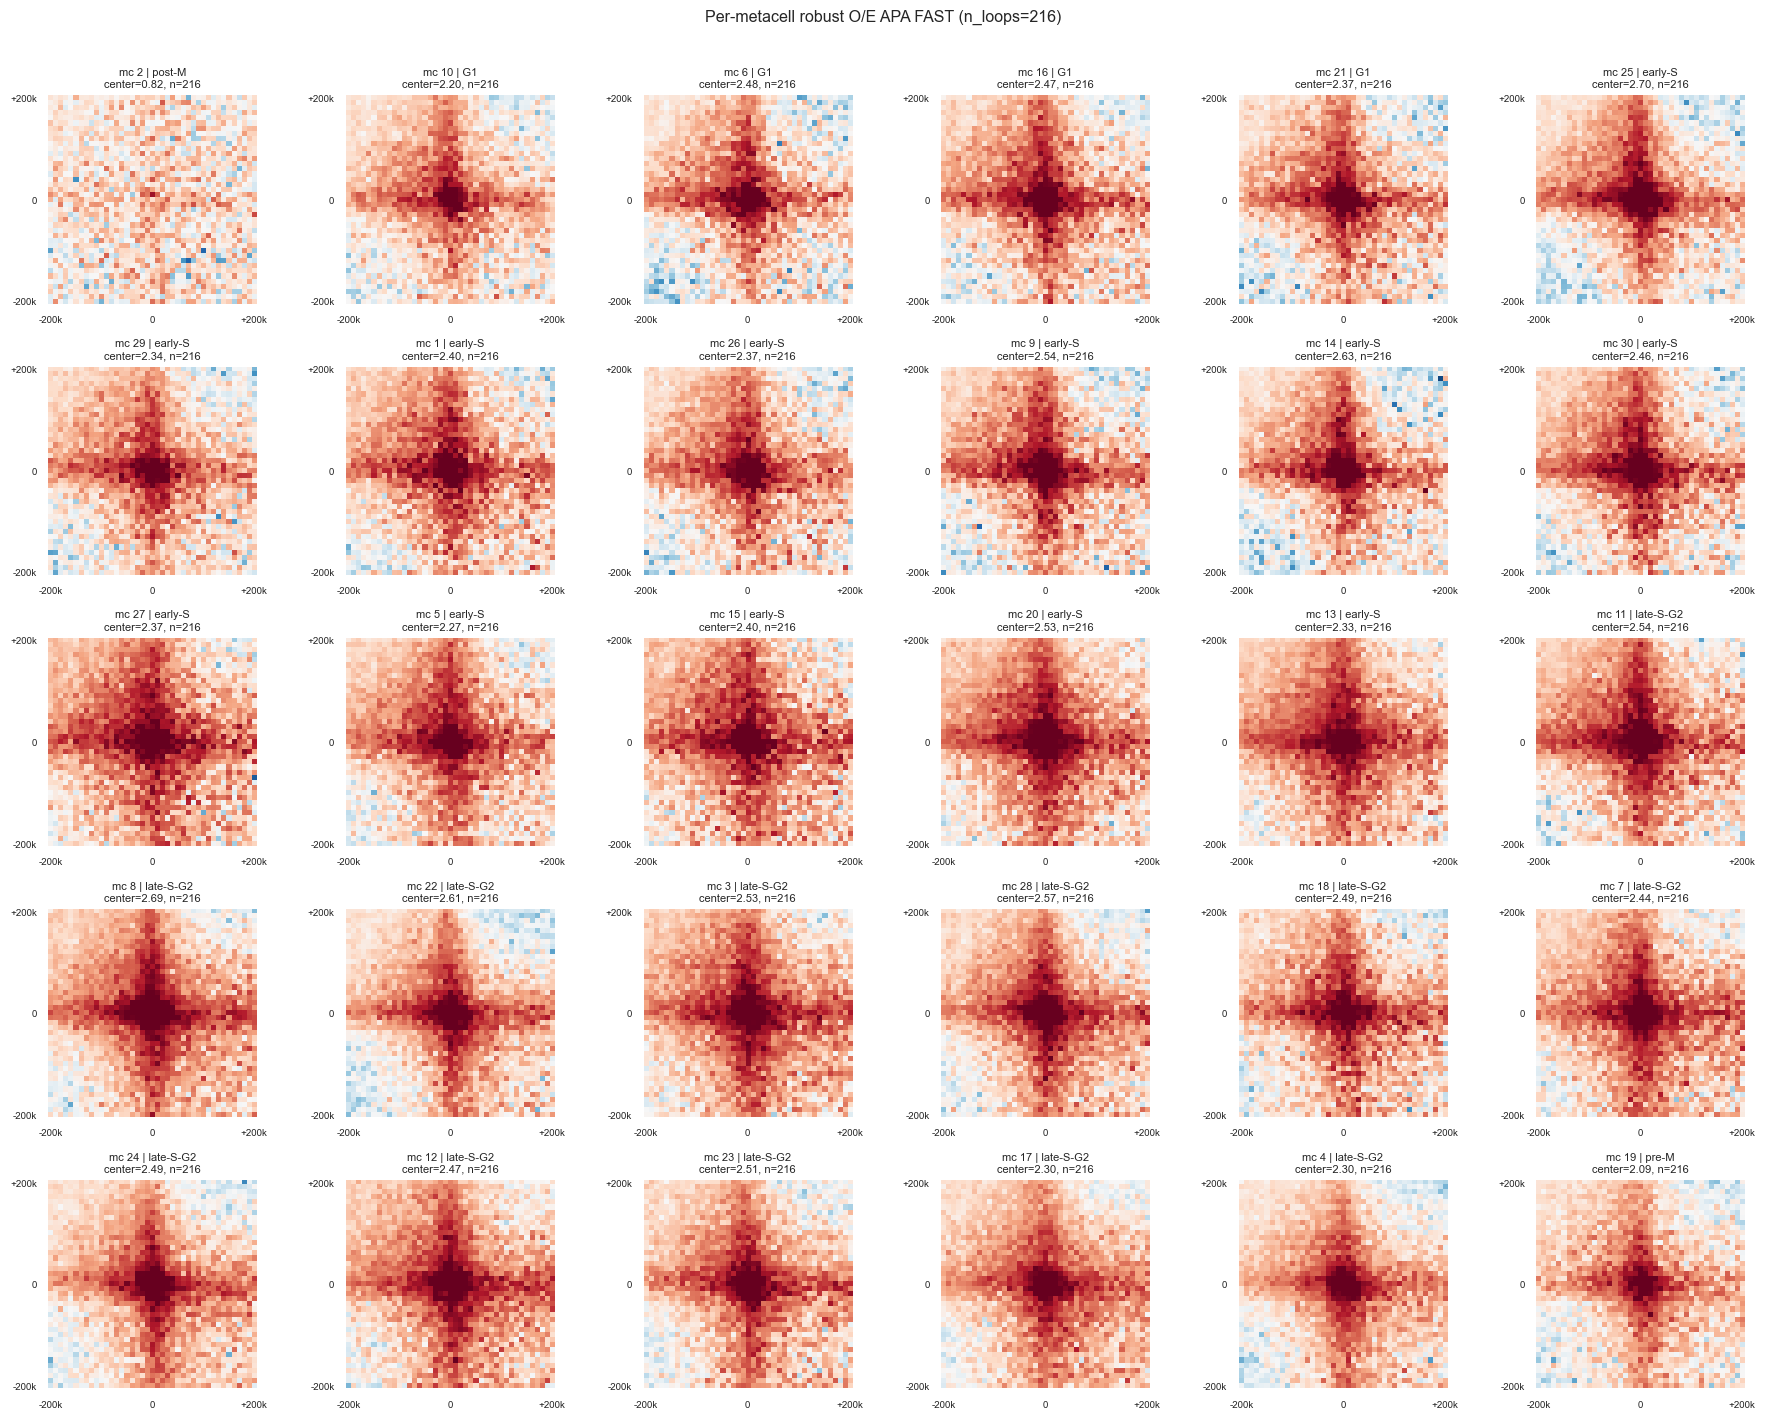

Saved: /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/metacell_apa_stats.allloops.OE_robust.fast.csv
Saved: /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/allloops_per_metacell_APA_grid_OE_robust.fast.pdf


In [84]:
# ================= 8-fast) 更快的稳健 O/E APA（稀疏 expected + 预分组 loops） =================
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
HALF_WIN = 20
# ---------- 可调参数（速度优先） ----------
MIN_LOOP_BP_ROBUST = 300_000
MAX_LOOP_BP_ROBUST = 700_000
PC_ROBUST = 1e-2



# 可选：最多使用多少 loops（None 表示全用）
MAX_LOOPS_USE = 12000

# loops 来源
if 'all_loop_df_from_mustache' in globals():
    loops_src2 = all_loop_df_from_mustache.copy()
else:
    loops_src2 = merged_loop_df.copy()

loops_src2['loop_bp'] = (loops_src2['bin2'] - loops_src2['bin1']) * APA_RES
loop_rb = loops_src2[loops_src2['loop_bp'] >= MIN_LOOP_BP_ROBUST].copy()
if MAX_LOOP_BP_ROBUST is not None:
    loop_rb = loop_rb[loop_rb['loop_bp'] <= MAX_LOOP_BP_ROBUST].copy()

# 如果有显著性列，优先保留更显著 loops
if 'fdr' in loop_rb.columns:
    loop_rb = loop_rb.sort_values('fdr', ascending=True)
elif 'scale' in loop_rb.columns:
    loop_rb = loop_rb.sort_values('scale', ascending=False)

if MAX_LOOPS_USE is not None and len(loop_rb) > MAX_LOOPS_USE:
    loop_rb = loop_rb.iloc[:MAX_LOOPS_USE].copy()

loop_rb = loop_rb[['chrom', 'bin1', 'bin2']].drop_duplicates().reset_index(drop=True)
print(f'Robust O/E loops used: {len(loop_rb)}')

# 预分组：避免每个 metacell 重建 by_chrom
loop_pairs_by_chrom = {}
for r in loop_rb.itertuples(index=False):
    loop_pairs_by_chrom.setdefault(r.chrom, []).append((int(r.bin1), int(r.bin2)))


def diag_expected_sparse(mat_csr):
    """
    稀疏 expected 估计：
    exp[d] = diagonal d 上 contact 总和 / (n-d)。
    使用 COO+bincount，避免整矩阵 toarray。
    """
    n = mat_csr.shape[0]
    tri = sp.triu(mat_csr, k=0).tocoo()
    d = (tri.col - tri.row).astype(np.int64)
    sum_d = np.bincount(d, weights=tri.data.astype(np.float64), minlength=n)
    denom = (n - np.arange(n, dtype=np.float64))
    return sum_d / np.maximum(denom, 1.0)


def extract_obs_exp_stack_fast(chrom_dict, loop_pairs_by_chrom, half_win=HALF_WIN):
    win = 2 * half_win + 1
    if not loop_pairs_by_chrom:
        z = np.zeros((0, win, win), dtype=np.float32)
        return z, z

    obs_patches, exp_patches = [], []
    for chrom, pairs in loop_pairs_by_chrom.items():
        if chrom not in chrom_dict:
            continue

        mat = chrom_dict[chrom]
        if mat is None or mat.nnz == 0:
            continue

        mat_csr = mat.tocsr()
        n = mat_csr.shape[0]
        exp_d = diag_expected_sparse(mat_csr)

        for b1, b2 in pairs:
            r0, r1 = b1 - half_win, b1 + half_win + 1
            c0, c1 = b2 - half_win, b2 + half_win + 1
            if r0 < 0 or c0 < 0 or r1 > n or c1 > n:
                continue

            obs = mat_csr[r0:r1, c0:c1].toarray().astype(np.float32)

            rows = np.arange(r0, r1)[:, None]
            cols = np.arange(c0, c1)[None, :]
            dd = np.abs(cols - rows).astype(np.int64)

            exp = np.zeros_like(obs, dtype=np.float32)
            valid = dd < len(exp_d)
            exp[valid] = exp_d[dd[valid]].astype(np.float32)

            obs_patches.append(obs)
            exp_patches.append(exp)

    if len(obs_patches) == 0:
        z = np.zeros((0, win, win), dtype=np.float32)
        return z, z

    return np.stack(obs_patches, axis=0), np.stack(exp_patches, axis=0)


mc_mat_dict_rb = hdata.metacell_data['mat'][str(APA_RES)]
metacell_ct = hdata.metacells.CellType.to_dict()

mc_apa_robust_fast = {}
mc_center_robust_fast = {}
mc_npatch_robust_fast = {}

for mc_id, chrom_dict_mc in mc_mat_dict_rb.items():
    obs_stack, exp_stack = extract_obs_exp_stack_fast(
        chrom_dict_mc, loop_pairs_by_chrom, half_win=HALF_WIN
    )
    mc_npatch_robust_fast[mc_id] = int(obs_stack.shape[0])

    if obs_stack.shape[0] == 0:
        mc_apa_robust_fast[mc_id] = np.zeros((2*HALF_WIN+1, 2*HALF_WIN+1), dtype=np.float32)
        mc_center_robust_fast[mc_id] = np.nan
    else:
        obs_mean = np.mean(obs_stack, axis=0)
        exp_mean = np.mean(exp_stack, axis=0)
        oe_map = np.log2((obs_mean + PC_ROBUST) / (exp_mean + PC_ROBUST))
        mc_apa_robust_fast[mc_id] = oe_map.astype(np.float32)
        c = HALF_WIN
        mc_center_robust_fast[mc_id] = float(np.mean(oe_map[c-1:c+2, c-1:c+2]))

print(
    'Robust O/E fast done:',
    sum(~np.isnan(np.array(list(mc_center_robust_fast.values())))),
    '/',
    len(mc_center_robust_fast),
)

# 绘图（与原版一致）
mc_to_plot = list(sorted_metacells)
n_mc = len(mc_to_plot)
if n_mc > 0:
    ncols = 6
    nrows = math.ceil(n_mc / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 2.8*nrows), squeeze=False)

    vals = []
    for mc_id in mc_to_plot:
        vals.append(mc_apa_robust_fast[mc_id].ravel())
    vals = np.concatenate(vals)
    vals = vals[np.isfinite(vals)]
    vmax = np.quantile(np.abs(vals), 0.98) if vals.size > 0 else 1.0
    vmax = max(vmax, 0.5)

    im = None
    for i, mc_id in enumerate(mc_to_plot):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        mat = mc_apa_robust_fast[mc_id]
        im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')

        ph = metacell_ct.get(mc_id, 'NA')
        center = mc_center_robust_fast.get(mc_id, np.nan)
        npatch = mc_npatch_robust_fast.get(mc_id, 0)
        ax.set_title(f'mc {mc_id} | {ph}\ncenter={center:.2f}, n={npatch}', fontsize=8)

        ax.set_xticks([0, HALF_WIN, 2*HALF_WIN])
        ax.set_yticks([0, HALF_WIN, 2*HALF_WIN])
        ax.set_xticklabels([f'-{HALF_WIN*APA_RES//1000}k', '0', f'+{HALF_WIN*APA_RES//1000}k'], fontsize=7)
        ax.set_yticklabels([f'-{HALF_WIN*APA_RES//1000}k', '0', f'+{HALF_WIN*APA_RES//1000}k'], fontsize=7)

    for j in range(n_mc, nrows*ncols):
        rr, cc = divmod(j, ncols)
        axes[rr][cc].axis('off')

    # cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
    cbar.set_label('robust log2(mean obs / mean exp)', fontsize=9)
    plt.suptitle(f'Per-metacell robust O/E APA FAST (n_loops={len(loop_rb)})', y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'allloops_per_metacell_APA_grid_OE_robust.fast.pdf', bbox_inches='tight')
    plt.show()

mc_stats_robust_fast = pd.DataFrame({
    'mc_id': list(mc_apa_robust_fast.keys()),
    'phase': [metacell_ct.get(mc, 'NA') for mc in mc_apa_robust_fast.keys()],
    'center_oe_robust': [mc_center_robust_fast.get(mc, np.nan) for mc in mc_apa_robust_fast.keys()],
    'n_loop_patches': [mc_npatch_robust_fast.get(mc, 0) for mc in mc_apa_robust_fast.keys()],
})
mc_stats_robust_fast.to_csv(OUT_DIR / 'metacell_apa_stats.allloops.OE_robust.fast.csv', index=False)
print('Saved:', OUT_DIR / 'metacell_apa_stats.allloops.OE_robust.fast.csv')
print('Saved:', OUT_DIR / 'allloops_per_metacell_APA_grid_OE_robust.fast.pdf')

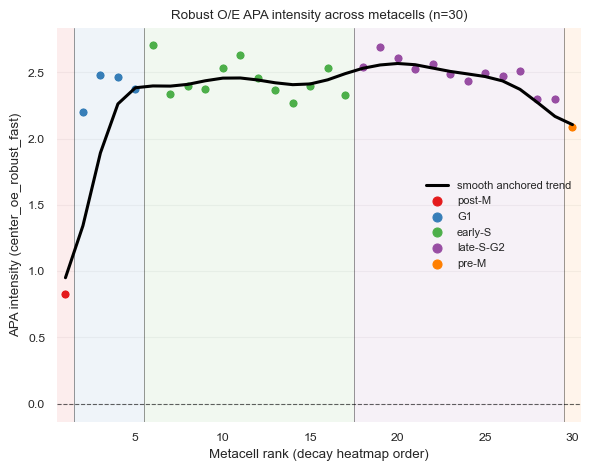

Saved: /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/metacell_APA_strength_line.robust_fast.anchored_tails.smooth.pdf
Saved: /Users/ckw/warehouse/metacell/stark/mustache_cycle_loops/metacell_APA_strength_line.robust_fast.anchored_tails.smooth.csv
Phase counts: {'early-S': 12, 'late-S-G2': 12, 'G1': 4, 'post-M': 1, 'pre-M': 1}
Points used for core LOWESS: 28 / 30
Left anchor applied (post-M -> G1): True
Right anchor applied (late-S-G2 -> pre-M): True
FINAL_SMOOTH_SIGMA: 0.8


In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess

# ================= 基于 robust fast O/E 的 APA 强度折线图（平滑锚定版） =================
if 'mc_center_robust_fast' not in globals():
    raise ValueError('未找到 mc_center_robust_fast，请先运行上一单元（8-fast robust O/E APA）。')

if 'sorted_metacells' in globals() and len(sorted_metacells) > 0:
    mc_order = list(sorted_metacells)
else:
    mc_order = list(mc_center_robust_fast.keys())

if len(mc_order) == 0:
    raise ValueError('metacell 列表为空，无法绘图。')

if 'metacell_ct' in globals():
    phase_map = metacell_ct
elif 'mc_ct' in globals():
    phase_map = mc_ct
else:
    phase_map = {}

phase_order_local = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = {
    'post-M': '#E41A1C',
    'G1': '#377EB8',
    'early-S': '#4DAF4A',
    'late-S-G2': '#984EA3',
    'pre-M': '#FF7F00',
}

# 核心 LOWESS 参数
LOWESS_FRAC = 0.30
LOWESS_IT = 2
MIN_PHASE_POINTS_FOR_FIT = 3

# 首尾锚定参数（桥接长度）
LEFT_BRIDGE_G1_POINTS = 5
RIGHT_BRIDGE_LATE_POINTS = 5

# 最后再做一层轻微平滑，去掉连接处的小折角
FINAL_SMOOTH_SIGMA = 0.8

x = np.arange(1, len(mc_order) + 1, dtype=float)
y = np.array([mc_center_robust_fast.get(mc, np.nan) for mc in mc_order], dtype=float)
phases = [phase_map.get(mc, 'NA') for mc in mc_order]
phase_arr = np.array(phases)

valid = np.isfinite(y)
if valid.sum() < 4:
    raise ValueError('有效数据点过少（<4），无法做可靠趋势拟合。')

# 1) 核心阶段 LOWESS（剔除单点 phase）
phase_counts = pd.Series(phases).value_counts().to_dict()
fit_mask = np.array([
    valid[i] and phase_counts.get(phases[i], 0) >= MIN_PHASE_POINTS_FOR_FIT
    for i in range(len(y))
])

if fit_mask.sum() < 4:
    fit_mask = valid.copy()

y_fit_partial = lowess(
    endog=y[fit_mask],
    exog=x[fit_mask],
    frac=LOWESS_FRAC,
    it=LOWESS_IT,
    return_sorted=False,
)

y_core = np.full_like(y, np.nan, dtype=float)
y_core[fit_mask] = y_fit_partial
y_core = pd.Series(y_core, index=x).interpolate(limit_direction='both').to_numpy()

y_smooth = y_core.copy()

# 2) 平滑锚定：用 smoothstep 曲线 + 余弦权重渐变融合
idx_post = np.where(phase_arr == 'post-M')[0]
idx_g1 = np.where(phase_arr == 'G1')[0]
idx_late = np.where(phase_arr == 'late-S-G2')[0]
idx_pre = np.where(phase_arr == 'pre-M')[0]

left_anchor_applied = False
right_anchor_applied = False

# 左端：post-M -> G1（上升）
if idx_post.size > 0 and idx_g1.size > 0:
    post_i = int(idx_post[0])
    g1_end_i = int(min(idx_g1[-1], idx_g1[0] + LEFT_BRIDGE_G1_POINTS - 1))

    post_val = y[post_i]
    g1_med = float(np.nanmedian(y[idx_g1])) if np.isfinite(y[idx_g1]).any() else np.nan

    if np.isfinite(post_val) and np.isfinite(g1_med) and g1_end_i >= post_i:
        n = g1_end_i - post_i + 1
        t = np.linspace(0.0, 1.0, n)

        # smoothstep：两端一阶导为0，更圆滑
        s = 3 * t**2 - 2 * t**3
        g1_target = max(g1_med, post_val + 1e-6)
        y_anchor_left = post_val + (g1_target - post_val) * s

        # 余弦权重：左侧锚定强，向右平滑过渡到核心 LOWESS
        w = 0.5 * (1.0 + np.cos(np.pi * t))
        y_smooth[post_i:g1_end_i + 1] = w * y_anchor_left + (1.0 - w) * y_core[post_i:g1_end_i + 1]

        # 强制非下降，明确 post-M->G1 上升趋势
        y_smooth[post_i:g1_end_i + 1] = np.maximum.accumulate(y_smooth[post_i:g1_end_i + 1])
        left_anchor_applied = True

# 右端：late-S-G2 -> pre-M（下降）
if idx_late.size > 0 and idx_pre.size > 0:
    late_start_i = int(max(idx_late[0], idx_late[-1] - RIGHT_BRIDGE_LATE_POINTS + 1))
    pre_i = int(idx_pre[-1])

    late_med = float(np.nanmedian(y[idx_late])) if np.isfinite(y[idx_late]).any() else np.nan
    pre_val = y[pre_i]

    if np.isfinite(late_med) and np.isfinite(pre_val) and pre_i >= late_start_i:
        n = pre_i - late_start_i + 1
        t = np.linspace(0.0, 1.0, n)

        s = 3 * t**2 - 2 * t**3
        pre_target = min(pre_val, late_med - 1e-6)
        y_anchor_right = late_med + (pre_target - late_med) * s

        # 余弦权重：右端锚定强，向左平滑回到核心 LOWESS
        w = 0.5 * (1.0 - np.cos(np.pi * t))
        y_smooth[late_start_i:pre_i + 1] = (1.0 - w) * y_core[late_start_i:pre_i + 1] + w * y_anchor_right

        # 强制非上升，明确 late-S-G2->pre-M 下降趋势
        seg = y_smooth[late_start_i:pre_i + 1].copy()
        for k in range(1, len(seg)):
            seg[k] = min(seg[k], seg[k - 1])
        y_smooth[late_start_i:pre_i + 1] = seg
        right_anchor_applied = True

# 3) 轻微全局平滑，去掉接缝处折角
if FINAL_SMOOTH_SIGMA > 0:
    y_smooth = gaussian_filter1d(y_smooth, sigma=FINAL_SMOOTH_SIGMA, mode='nearest')

fig, ax = plt.subplots(figsize=(6, 4.8))

start = 0
while start < len(mc_order):
    ph = phases[start]
    end = start
    while end + 1 < len(mc_order) and phases[end + 1] == ph:
        end += 1
    ax.axvspan(start + 0.5, end + 1.5, color=phase_colors.get(ph, '#CCCCCC'), alpha=0.08, lw=0)
    if end + 1 < len(mc_order):
        ax.axvline(end + 1.5, color='black', lw=0.7, alpha=0.4)
    start = end + 1

for xi, yi, ph in zip(x, y, phases):
    ax.scatter(xi, yi, s=42, color=phase_colors.get(ph, 'gray'), edgecolors='white', linewidth=0.5, zorder=3)

ax.plot(
    x,
    y_smooth,
    color='black',
    lw=2.2,
    label='smooth anchored trend',
    zorder=4,
)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)

ax.set_xlim(0.5, len(mc_order) + 0.5)
ax.set_xlabel('Metacell rank (decay heatmap order)')
ax.set_ylabel('APA intensity (center_oe_robust_fast)')
ax.set_title(f'Robust O/E APA intensity across metacells (n={len(mc_order)})')
ax.grid(axis='y', alpha=0.2)

for ph in phase_order_local:
    ax.scatter([], [], s=42, color=phase_colors[ph], label=ph)
ax.legend(loc='best', fontsize=8, frameon=False)

plt.tight_layout()

out_dir = OUT_DIR if 'OUT_DIR' in globals() else Path.cwd()
out_pdf = out_dir / 'metacell_APA_strength_line.robust_fast.anchored_tails.smooth.pdf'
out_csv = out_dir / 'metacell_APA_strength_line.robust_fast.anchored_tails.smooth.csv'

plt.savefig(out_pdf, bbox_inches='tight')
plt.show()

line_df = pd.DataFrame({
    'rank': x.astype(int),
    'mc_id': mc_order,
    'phase': phases,
    'center_oe_robust_fast': y,
    'center_oe_robust_fast_anchored_tails_smooth': y_smooth,
})
line_df.to_csv(out_csv, index=False)

print('Saved:', out_pdf)
print('Saved:', out_csv)
print('Phase counts:', phase_counts)
print('Points used for core LOWESS:', int(fit_mask.sum()), '/', int(valid.sum()))
print('Left anchor applied (post-M -> G1):', left_anchor_applied)
print('Right anchor applied (late-S-G2 -> pre-M):', right_anchor_applied)
print('FINAL_SMOOTH_SIGMA:', FINAL_SMOOTH_SIGMA)

In [85]:
chrom = 'chr11'
resolution = 1000000
start =0
end=122082543
# sk.pl.plot_metacell_region(hdata, chrom, start, end, resolution,
#                          balance=True, base_on='mat', ncols=4, celltype=None,
#                          cell_type_col='CellType', cmap='Reds',vmax=5,named_on='CellType',
#                          log1p=True, fill_diagonal_zero=True, save_path=OUT_DIR / f'{chrom}_{start}_{end}_metacell_region.pdf'  )

In [86]:
# # ================= 8-hybrid) Distance-OE + Local Detrend APA =================
# import math
# import numpy as np
# import pandas as pd
# import scipy.sparse as sp
# import matplotlib.pyplot as plt

# # ---------- 参数（可调） ----------
# HALF_WIN_HYB = 10
# CENTER_HALF_HYB = 1
# PC_HYB = 1e-6

# # 对 O/E 图做局部去趋势（减去环形中位数）
# RING_INNER_HYB = 4
# RING_OUTER_HYB = 9

# MIN_LOOP_BP_HYB = 350_000
# MAX_LOOP_BP_HYB = 800_000
# MAX_LOOPS_USE_HYB = 12000

# # loops 来源
# if 'all_loop_df_from_mustache' in globals():
#     loops_src_hyb = all_loop_df_from_mustache.copy()
# else:
#     loops_src_hyb = merged_loop_df.copy()

# loops_src_hyb['loop_bp'] = (loops_src_hyb['bin2'] - loops_src_hyb['bin1']) * APA_RES
# loop_hyb = loops_src_hyb[loops_src_hyb['loop_bp'] >= MIN_LOOP_BP_HYB].copy()
# if MAX_LOOP_BP_HYB is not None:
#     loop_hyb = loop_hyb[loop_hyb['loop_bp'] <= MAX_LOOP_BP_HYB].copy()

# if 'fdr' in loop_hyb.columns:
#     loop_hyb = loop_hyb.sort_values('fdr', ascending=True)
# elif 'scale' in loop_hyb.columns:
#     loop_hyb = loop_hyb.sort_values('scale', ascending=False)

# if MAX_LOOPS_USE_HYB is not None and len(loop_hyb) > MAX_LOOPS_USE_HYB:
#     loop_hyb = loop_hyb.iloc[:MAX_LOOPS_USE_HYB].copy()

# loop_hyb = loop_hyb[['chrom', 'bin1', 'bin2']].drop_duplicates().reset_index(drop=True)
# print(f'Hybrid APA loops used: {len(loop_hyb)}')

# # 预分组 loops
# loop_pairs_by_chrom_hyb = {}
# for r in loop_hyb.itertuples(index=False):
#     loop_pairs_by_chrom_hyb.setdefault(r.chrom, []).append((int(r.bin1), int(r.bin2)))


# def diag_expected_sparse(mat_csr):
#     """Distance-only expected: exp[d] = sum(diagonal d) / (n-d)."""
#     n = mat_csr.shape[0]
#     tri = sp.triu(mat_csr, k=0).tocoo()
#     d = (tri.col - tri.row).astype(np.int64)
#     sum_d = np.bincount(d, weights=tri.data.astype(np.float64), minlength=n)
#     denom = (n - np.arange(n, dtype=np.float64))
#     return sum_d / np.maximum(denom, 1.0)


# def extract_obs_exp_stack_fast(chrom_dict, loop_pairs_by_chrom, half_win=10):
#     """提取 obs/exp patch stack（exp 按距离向量索引）。"""
#     win = 2 * half_win + 1
#     if not loop_pairs_by_chrom:
#         z = np.zeros((0, win, win), dtype=np.float32)
#         return z, z

#     obs_patches, exp_patches = [], []
#     for chrom, pairs in loop_pairs_by_chrom.items():
#         if chrom not in chrom_dict:
#             continue

#         mat = chrom_dict[chrom]
#         if mat is None or mat.nnz == 0:
#             continue

#         mat_csr = mat.tocsr()
#         n = mat_csr.shape[0]
#         exp_d = diag_expected_sparse(mat_csr)

#         for b1, b2 in pairs:
#             r0, r1 = b1 - half_win, b1 + half_win + 1
#             c0, c1 = b2 - half_win, b2 + half_win + 1
#             if r0 < 0 or c0 < 0 or r1 > n or c1 > n:
#                 continue

#             obs = mat_csr[r0:r1, c0:c1].toarray().astype(np.float32)

#             rows = np.arange(r0, r1)[:, None]
#             cols = np.arange(c0, c1)[None, :]
#             dd = np.abs(cols - rows).astype(np.int64)

#             exp = np.zeros_like(obs, dtype=np.float32)
#             valid = dd < len(exp_d)
#             exp[valid] = exp_d[dd[valid]].astype(np.float32)

#             obs_patches.append(obs)
#             exp_patches.append(exp)

#     if len(obs_patches) == 0:
#         z = np.zeros((0, win, win), dtype=np.float32)
#         return z, z

#     return np.stack(obs_patches, axis=0), np.stack(exp_patches, axis=0)


# def ring_median(mat, center_half=1, ring_inner=4, ring_outer=9):
#     """在 O/E 图上取环形区域中位数，作为局部趋势项。"""
#     w = mat.shape[0]
#     c = w // 2
#     yy, xx = np.indices((w, w))
#     d = np.sqrt((yy - c) ** 2 + (xx - c) ** 2)

#     center_mask = (np.abs(yy - c) <= center_half) & (np.abs(xx - c) <= center_half)
#     ring_mask = (d >= ring_inner) & (d <= ring_outer) & (~center_mask)

#     vals = mat[ring_mask]
#     vals = vals[np.isfinite(vals)]
#     if vals.size == 0:
#         return np.nan
#     return float(np.median(vals))


# mc_mat_dict_hyb = hdata.metacell_data['mat'][str(APA_RES)]
# metacell_ct = hdata.metacells.CellType.to_dict()

# mc_apa_hybrid = {}
# mc_center_hybrid = {}
# mc_ring_med_hybrid = {}
# mc_npatch_hybrid = {}

# for mc_id, chrom_dict_mc in mc_mat_dict_hyb.items():
#     obs_stack, exp_stack = extract_obs_exp_stack_fast(
#         chrom_dict_mc,
#         loop_pairs_by_chrom_hyb,
#         half_win=HALF_WIN_HYB,
#     )
#     mc_npatch_hybrid[mc_id] = int(obs_stack.shape[0])

#     if obs_stack.shape[0] == 0:
#         w = 2 * HALF_WIN_HYB + 1
#         mc_apa_hybrid[mc_id] = np.zeros((w, w), dtype=np.float32)
#         mc_center_hybrid[mc_id] = np.nan
#         mc_ring_med_hybrid[mc_id] = np.nan
#         continue

#     obs_mean = np.mean(obs_stack, axis=0)
#     exp_mean = np.mean(exp_stack, axis=0)

#     # 第一步：按距离做 O/E
#     oe_dist = np.log2((obs_mean + PC_HYB) / (exp_mean + PC_HYB))

#     # 第二步：减去局部环形中位数，去掉残余局部倾斜
#     med_ring = ring_median(
#         oe_dist,
#         center_half=CENTER_HALF_HYB,
#         ring_inner=RING_INNER_HYB,
#         ring_outer=RING_OUTER_HYB,
#     )
#     if np.isfinite(med_ring):
#         oe_hybrid = oe_dist - med_ring
#     else:
#         oe_hybrid = oe_dist.copy()

#     mc_apa_hybrid[mc_id] = oe_hybrid.astype(np.float32)
#     c = HALF_WIN_HYB
#     mc_center_hybrid[mc_id] = float(np.mean(oe_hybrid[c-1:c+2, c-1:c+2]))
#     mc_ring_med_hybrid[mc_id] = med_ring

# vals_center = np.array(list(mc_center_hybrid.values()), dtype=float)
# print('Hybrid center score valid:', np.isfinite(vals_center).sum(), '/', len(vals_center))
# if np.isfinite(vals_center).any():
#     print('Hybrid center min/median/max:', np.nanmin(vals_center), np.nanmedian(vals_center), np.nanmax(vals_center))

# # 绘图
# mc_to_plot = list(sorted_metacells) if 'sorted_metacells' in globals() else list(mc_apa_hybrid.keys())
# n_mc = len(mc_to_plot)
# if n_mc > 0:
#     ncols = 6
#     nrows = math.ceil(n_mc / ncols)
#     fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.8 * nrows), squeeze=False)

#     vals = np.concatenate([mc_apa_hybrid[mc].ravel() for mc in mc_to_plot])
#     vals = vals[np.isfinite(vals)]
#     vmax = np.quantile(np.abs(vals), 0.98) if vals.size > 0 else 1.0
#     vmax = max(float(vmax), 0.25)

#     im = None
#     for i, mc_id in enumerate(mc_to_plot):
#         rr, cc = divmod(i, ncols)
#         ax = axes[rr][cc]
#         mat = mc_apa_hybrid[mc_id]
#         im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')

#         ph = metacell_ct.get(mc_id, 'NA')
#         center = mc_center_hybrid.get(mc_id, np.nan)
#         npatch = mc_npatch_hybrid.get(mc_id, 0)
#         ax.set_title(f'mc {mc_id} | {ph}\ncenter={center:.2f}, n={npatch}', fontsize=8)

#         ax.set_xticks([0, HALF_WIN_HYB, 2 * HALF_WIN_HYB])
#         ax.set_yticks([0, HALF_WIN_HYB, 2 * HALF_WIN_HYB])
#         ax.set_xticklabels([f'-{HALF_WIN_HYB * APA_RES // 1000}k', '0', f'+{HALF_WIN_HYB * APA_RES // 1000}k'], fontsize=7)
#         ax.set_yticklabels([f'-{HALF_WIN_HYB * APA_RES // 1000}k', '0', f'+{HALF_WIN_HYB * APA_RES // 1000}k'], fontsize=7)

#     for j in range(n_mc, nrows * ncols):
#         rr, cc = divmod(j, ncols)
#         axes[rr][cc].axis('off')

#     # cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
#     cbar.set_label('hybrid log2(obs/exp) - local ring median', fontsize=9)
#     plt.suptitle(f'Per-metacell Hybrid APA (distance O/E + local detrend, n_loops={len(loop_hyb)})', y=1.01)
#     plt.tight_layout()

#     out_dir_hyb = OUT_DIR if 'OUT_DIR' in globals() else Path.cwd()
#     plt.savefig(out_dir_hyb / 'allloops_per_metacell_APA_grid_hybrid.pdf', bbox_inches='tight')
#     plt.show()

# # 导出统计
# mc_stats_hybrid = pd.DataFrame({
#     'mc_id': list(mc_apa_hybrid.keys()),
#     'phase': [metacell_ct.get(mc, 'NA') for mc in mc_apa_hybrid.keys()],
#     'center_hybrid': [mc_center_hybrid.get(mc, np.nan) for mc in mc_apa_hybrid.keys()],
#     'ring_median_oe': [mc_ring_med_hybrid.get(mc, np.nan) for mc in mc_apa_hybrid.keys()],
#     'n_loop_patches': [mc_npatch_hybrid.get(mc, 0) for mc in mc_apa_hybrid.keys()],
# })

# out_dir_hyb = OUT_DIR if 'OUT_DIR' in globals() else Path.cwd()
# mc_stats_hybrid.to_csv(out_dir_hyb / 'metacell_apa_stats.allloops.hybrid.csv', index=False)
# print('Saved:', out_dir_hyb / 'metacell_apa_stats.allloops.hybrid.csv')
# print('Saved:', out_dir_hyb / 'allloops_per_metacell_APA_grid_hybrid.pdf')

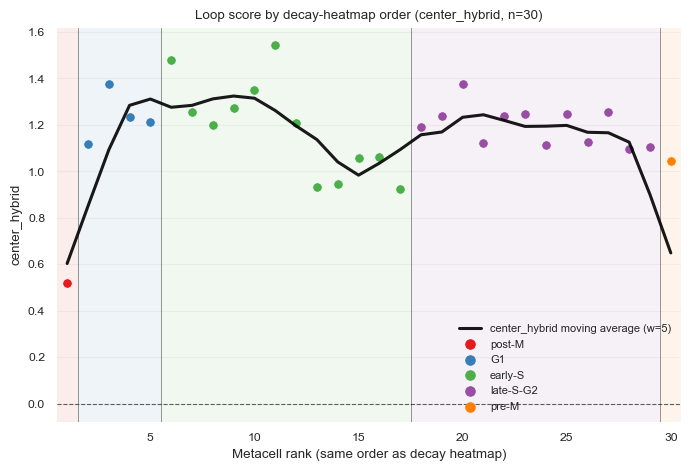

In [87]:
# ================= loop折线图（hybrid逻辑复刻 + 与旧线对照） =================
import numpy as np
import matplotlib.pyplot as plt

# 1) 使用与 decay heatmap 一致的 metacell 顺序
order = list(sorted_metacells)
if len(order) == 0:
    raise ValueError('sorted_metacells 为空，请先运行 decay heatmap 排序单元。')

# 2) 新逻辑：优先使用 hybrid 指标
if 'mc_center_hybrid' in globals():
    loop_score_map_new = mc_center_hybrid
    score_name_new = 'center_hybrid'
elif 'mc_center_oe_localbg' in globals():
    loop_score_map_new = mc_center_oe_localbg
    score_name_new = 'center_oe_localbg'
elif 'mc_center_robust_fast' in globals():
    loop_score_map_new = mc_center_robust_fast
    score_name_new = 'center_oe_robust_fast'
else:
    raise ValueError('未找到 hybrid/localbg/robust 指标，请先运行相应 APA 单元。')

# 旧逻辑指标（用于对照）
if 'mc_center_robust_fast' in globals():
    loop_score_map_old = mc_center_robust_fast
    score_name_old = 'center_oe_robust_fast'
elif 'mc_center_robust' in globals():
    loop_score_map_old = mc_center_robust
    score_name_old = 'center_oe_robust'
elif 'mc_center_oe' in globals():
    loop_score_map_old = mc_center_oe
    score_name_old = 'center_oe'
elif 'mc_enrichment_allloops' in globals():
    loop_score_map_old = mc_enrichment_allloops
    score_name_old = 'apa_enrichment_allloops'
else:
    loop_score_map_old = None
    score_name_old = None

# 3) phase 信息
if 'metacell_ct' in globals():
    phase_map = metacell_ct
elif 'mc_ct' in globals():
    phase_map = mc_ct
else:
    phase_map = {}

phase_order_local = ['post-M', 'G1', 'early-S', 'late-S-G2', 'pre-M']
phase_colors = {
    'post-M': '#E41A1C',
    'G1': '#377EB8',
    'early-S': '#4DAF4A',
    'late-S-G2': '#984EA3',
    'pre-M': '#FF7F00',
}

x = np.arange(1, len(order) + 1)
y_new = np.array([loop_score_map_new.get(mc, np.nan) for mc in order], dtype=float)
phase_per_mc = [phase_map.get(mc, 'NA') for mc in order]

# 4) 复刻原风格画图（phase 背景 + 彩点 + moving average）
fig, ax = plt.subplots(figsize=(7, 4.8))

start = 1
for ph in phase_order_local:
    idxs = [i + 1 for i, mc in enumerate(order) if phase_map.get(mc, 'NA') == ph]
    if len(idxs) == 0:
        continue
    end = idxs[-1]
    ax.axvspan(start - 0.5, end + 0.5, color=phase_colors.get(ph, '#cccccc'), alpha=0.08, lw=0)
    ax.axvline(end + 0.5, color='black', lw=0.7, alpha=0.4)
    start = end + 1

for xi, yi, ph in zip(x, y_new, phase_per_mc):
    ax.scatter(xi, yi, s=46, color=phase_colors.get(ph, 'gray'), edgecolors='white', linewidth=0.5, zorder=3)

if len(y_new) >= 5:
    yy = y_new.copy()
    valid = np.isfinite(yy)
    if valid.any():
        yy[~valid] = np.nanmedian(yy[valid])
        w = 5
        kernel = np.ones(w, dtype=float) / w
        y_smooth_new = np.convolve(yy, kernel, mode='same')
        ax.plot(x, y_smooth_new, color='black', lw=2.2, alpha=0.9, zorder=4, label=f'{score_name_new} moving average (w=5)')

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_xlim(0.5, len(order) + 0.5)
ax.set_xlabel('Metacell rank (same order as decay heatmap)')
ax.set_ylabel(score_name_new)
ax.set_title(f'Loop score by decay-heatmap order ({score_name_new}, n={len(order)})')
ax.grid(axis='y', alpha=0.2)

for ph in phase_order_local:
    ax.scatter([], [], color=phase_colors[ph], s=46, label=ph)
ax.legend(loc='best', fontsize=8, frameon=False)

plt.tight_layout()
out_dir = OUT_DIR if 'OUT_DIR' in globals() else Path.cwd()
plt.savefig(out_dir / f'loop_line_by_decay_order.{score_name_new}.replica.pdf', bbox_inches='tight')
plt.show()


In [32]:
# metacell id -> decay heatmap idx + label
import pandas as pd

if 'sorted_metacells' not in globals() or len(sorted_metacells) == 0:
    raise ValueError('sorted_metacells 不存在或为空，请先运行 decay heatmap 排序单元。')

if 'metacell_ct' in globals():
    label_map = dict(metacell_ct)
elif hasattr(hdata, 'metacells') and ('CellType' in hdata.metacells.columns):
    label_map = hdata.metacells['CellType'].to_dict()
else:
    label_map = {}

mc_decay_idx_df = pd.DataFrame({
    'mc_id': list(sorted_metacells),
    'decay_heatmap_idx': list(range(len(sorted_metacells))),
})
mc_decay_idx_df['label'] = mc_decay_idx_df['mc_id'].map(label_map).fillna('NA')

mc_decay_idx_df

,mc_id,decay_heatmap_idx,label
0,2,0,post-M
1,10,1,G1
2,6,2,G1
3,16,3,G1
4,21,4,G1
5,25,5,early-S
6,29,6,early-S
7,1,7,early-S
8,26,8,early-S
9,9,9,early-S
